# 30-Day Hospital Readmission Risk Modeling with PyTorch

**Dataset:** UCI *Diabetes 130-US Hospitals for Years 1999–2008*  
**Prediction time:** hospital discharge  
**Outcome:** readmission within 30 days

## Research question

Using information available by the time of hospital discharge, can we estimate the probability that a patient with diabetes will be readmitted within 30 days?

This notebook is structured as a small clinical-informatics prediction analysis rather than an accuracy-focused Kaggle exercise. The emphasis is on cohort definition, leakage prevention, clinically interpretable feature construction, discrimination, calibration, threshold tradeoffs, and a transparent PyTorch implementation.

### Analysis principles

- Define the cohort and prediction time before modeling.
- Exclude information that directly reveals the future outcome.
- Keep the final test set untouched during feature/model development and threshold selection.
- Fit learned preprocessing steps on the training set only.
- Evaluate probability quality and calibration in addition to ranking metrics.
- Treat associations and predictions as non-causal.

**Primary references**

- UCI Machine Learning Repository, dataset 296: *Diabetes 130-US Hospitals for Years 1999–2008* — https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
- Strack et al. (2014), *Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records* — https://doi.org/10.1155/2014/781670

# Phase 1 — Data acquisition and cohort definition

The public UCI release contains hospital encounters rather than one row per independent patient. Phase 1 therefore establishes the raw data structure, defines the binary outcome, removes encounters that are not meaningful candidates for post-discharge readmission, and restricts the primary analysis to one qualifying released encounter per patient.

## 1.1 Load the official UCI dataset

The analysis uses UCI dataset ID 296 through `ucimlrepo`. `diabetes.data.original` is retained because the identifier columns are needed for cohort construction even though they will not be model predictors.

In [72]:
!pip -q install -U ucimlrepo

import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

# Official UCI dataset:
# Diabetes 130-US Hospitals for Years 1999-2008
diabetes = fetch_ucirepo(id=296)

print("Dataset loaded.")

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Dataset loaded.


## 1.2 Inspect the raw schema

The first pass checks dataset dimensions, identifiers, pandas dtypes, UCI variable metadata, target prevalence, repeated patients, and the representation of missing values. At this point no filtering or modeling transformations are applied.

A recurring distinction in this dataset is that **storage dtype is not the same as modeling type**. For example, `admission_type_id`, `admission_source_id`, and `discharge_disposition_id` are integer-valued categorical codes, whereas variables such as `time_in_hospital` and `num_lab_procedures` are quantitative counts.

In [73]:
print("UCI dataset name:", diabetes.metadata.name)
print("Reported instances:", diabetes.metadata.num_instances)
print("Reported features:", diabetes.metadata.num_features)

print("\nComponent shapes:")
print("IDs:     ", diabetes.data.ids.shape)
print("Features:", diabetes.data.features.shape)
print("Targets: ", diabetes.data.targets.shape)
print("Original:", diabetes.data.original.shape)

UCI dataset name: Diabetes 130-US Hospitals for Years 1999-2008
Reported instances: 101766
Reported features: 47

Component shapes:
IDs:      (101766, 2)
Features: (101766, 47)
Targets:  (101766, 1)
Original: (101766, 50)


In [74]:
df_raw = diabetes.data.original.copy()

print("Shape:", df_raw.shape)

print("\nColumns:")
print(df_raw.columns.tolist())

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nDataFrame info:")
df_raw.info()

Shape: (101766, 50)

Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null 

In [75]:
variable_info = diabetes.variables[
    ["name", "role", "type", "missing_values"]
].copy()

display(variable_info)

,name,role,type,missing_values
0,encounter_id,ID,,no
1,patient_nbr,ID,,no
2,race,Feature,Categorical,yes
3,gender,Feature,Categorical,no
4,age,Feature,Categorical,no
5,weight,Feature,Categorical,yes
6,admission_type_id,Feature,Categorical,no
7,discharge_disposition_id,Feature,Categorical,no
8,admission_source_id,Feature,Categorical,no
9,time_in_hospital,Feature,Integer,no


In [76]:
# 1. Raw outcome distribution
print("READMISSION TARGET")
print(df_raw["readmitted"].value_counts(dropna=False))

print("\nPercentages:")
print(
    df_raw["readmitted"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

# 2. Encounters versus patients
print("\nPATIENT / ENCOUNTER COUNTS")
print("Rows:", len(df_raw))
print("Unique encounter_id:", df_raw["encounter_id"].nunique())
print("Unique patient_nbr:", df_raw["patient_nbr"].nunique())

encounters_per_patient = df_raw.groupby("patient_nbr").size()

print("\nEncounters per patient:")
print(encounters_per_patient.describe())

print(
    "\nPatients with >1 encounter:",
    (encounters_per_patient > 1).sum()
)

# 3. Missing values recognized by pandas
missing_na = df_raw.isna().sum().sort_values(ascending=False)

print("\nTOP COLUMNS WITH NaN MISSINGNESS")
display(
    missing_na[missing_na > 0]
    .to_frame("n_missing")
    .assign(
        pct_missing=lambda x:
        (100 * x["n_missing"] / len(df_raw)).round(2)
    )
)

# 4. Check whether literal '?' values remain
object_cols = df_raw.select_dtypes(include=["object", "string"]).columns

question_mark_counts = (
    df_raw[object_cols]
    .eq("?")
    .sum()
    .sort_values(ascending=False)
)

print("\nCOLUMNS CONTAINING LITERAL '?'")
display(question_mark_counts[question_mark_counts > 0])

READMISSION TARGET
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentages:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

PATIENT / ENCOUNTER COUNTS
Rows: 101766
Unique encounter_id: 101766
Unique patient_nbr: 71518

Encounters per patient:
count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64

Patients with >1 encounter: 16773

TOP COLUMNS WITH NaN MISSINGNESS


,n_missing,pct_missing
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02



COLUMNS CONTAINING LITERAL '?'


,0


In [77]:
df_raw[
    [
        "admission_type_id",
        "admission_source_id",
        "discharge_disposition_id",
        "time_in_hospital",
        "num_lab_procedures",
        "diag_1",
        "diag_2",
        "diag_3",
    ]
].dtypes

,0
admission_type_id,int64
admission_source_id,int64
discharge_disposition_id,int64
time_in_hospital,int64
num_lab_procedures,int64
diag_1,object
diag_2,object
diag_3,object


In [78]:
df_raw[["diag_1", "diag_2", "diag_3"]].head(10)

,diag_1,diag_2,diag_3
0,250.83,NaN,NaN
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


### Initial observations

- The raw file contains **101,766 encounters** but only **71,518 unique patients**, so repeated encounters from the same patient are common.
- The raw `<30` outcome prevalence is about **11.2%**, making accuracy a poor primary metric: a classifier that predicts no early readmissions for everyone would already appear highly accurate.
- Missingness is highly variable across fields. In particular, `weight`, `max_glu_serum`, and `A1Cresult` are missing for most encounters, while diagnosis fields are nearly complete.
- `ucimlrepo` has converted the historical missing-value sentinel values into pandas `NaN` in this load.

## 1.3 Verify death/hospice discharge codes

Prediction time is discharge. Encounters ending in death or hospice are excluded because they represent a different post-discharge risk process and, for death, ordinary 30-day readmission is not possible. The official `IDS_mapping.csv` distributed with the dataset is used to verify the disposition codes rather than relying on an undocumented secondary source.

In [79]:
import io
import zipfile
import requests

UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/296/"
    "diabetes%2B130-us%2Bhospitals%2Bfor%2Byears%2B1999-2008.zip"
)

response = requests.get(UCI_ZIP_URL)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files in official UCI archive:")
    print(z.namelist())

    mapping_text = z.read("IDS_mapping.csv").decode("utf-8-sig")

start = mapping_text.index("discharge_disposition_id")
end = mapping_text.index("admission_source_id")

print("\nDischarge disposition mapping:\n")
print(mapping_text[start:end])

Files in official UCI archive:
['diabetic_data.csv', 'IDS_mapping.csv']

Discharge disposition mapping:

discharge_disposition_id,description
1,Discharged to home
2,Discharged/transferred to another short term hospital
3,Discharged/transferred to SNF
4,Discharged/transferred to ICF
5,Discharged/transferred to another type of inpatient care institution
6,Discharged/transferred to home with home health service
7,Left AMA
8,Discharged/transferred to home under care of Home IV provider
9,Admitted as an inpatient to this hospital
10,Neonate discharged to another hospital for neonatal aftercare
11,Expired
12,Still patient or expected to return for outpatient services
13,Hospice / home
14,Hospice / medical facility
15,Discharged/transferred within this institution to Medicare approved swing bed
16,Discharged/transferred/referred another institution for outpatient services
17,Discharged/transferred/referred to this institution for outpatient services
18,NULL
19,"Expired at home. Medicaid only,

In [80]:
EXCLUDED_DISPOSITIONS = {11, 13, 14, 19, 20, 21}

excluded_counts = (
    df_raw.loc[
        df_raw["discharge_disposition_id"].isin(EXCLUDED_DISPOSITIONS),
        "discharge_disposition_id"
    ]
    .value_counts()
    .sort_index()
)

print(excluded_counts)

print(
    "\nTotal encounters marked death/hospice:",
    excluded_counts.sum()
)

print(
    "Percent of raw encounters:",
    round(100 * excluded_counts.sum() / len(df_raw), 2),
    "%"
)

discharge_disposition_id
11    1642
13     399
14     372
19       8
20       2
Name: count, dtype: int64

Total encounters marked death/hospice: 2423
Percent of raw encounters: 2.38 %


## 1.4 Construct the analytical cohort and binary target

The primary cohort definition used in this project is:

1. remove death/hospice encounters;
2. define `readmit_30d = 1` when `readmitted == "<30"`, otherwise `0`;
3. retain the first **qualifying released record** for each `patient_nbr`.

This produces one row per patient in the main analysis and prevents patient overlap across later train/validation/test splits. It does **not** imply that all remaining observations are perfectly IID; hospital-level and other clustering may remain.

In [81]:
df_eligible = df_raw.loc[
    ~df_raw["discharge_disposition_id"].isin(EXCLUDED_DISPOSITIONS)
].copy()

print("Raw encounters:", len(df_raw))
print("Eligible encounters:", len(df_eligible))
print("Excluded:", len(df_raw) - len(df_eligible))

print("\nUnique patients among eligible encounters:")
print(df_eligible["patient_nbr"].nunique())

Raw encounters: 101766
Eligible encounters: 99343
Excluded: 2423

Unique patients among eligible encounters:
69990


In [82]:
df_eligible["readmit_30d"] = (
    df_eligible["readmitted"] == "<30"
).astype("int8")

print(df_eligible["readmit_30d"].value_counts())
print()

print(
    df_eligible["readmit_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmit_30d
0    88029
1    11314
Name: count, dtype: int64

readmit_30d
0    88.61
1    11.39
Name: proportion, dtype: float64


In [83]:
df_cohort = (
    df_eligible
    .drop_duplicates(subset="patient_nbr", keep="first")
    .copy()
)

print("Eligible encounters:", len(df_eligible))
print("Final cohort rows:", len(df_cohort))
print("Unique patients:", df_cohort["patient_nbr"].nunique())

assert len(df_cohort) == df_cohort["patient_nbr"].nunique()

print("\nFinal target distribution:")
print(df_cohort["readmit_30d"].value_counts())

print("\nFinal target prevalence:")
print(
    df_cohort["readmit_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Eligible encounters: 99343
Final cohort rows: 69990
Unique patients: 69990

Final target distribution:
readmit_30d
0    63705
1     6285
Name: count, dtype: int64

Final target prevalence:
readmit_30d
0    91.02
1     8.98
Name: proportion, dtype: float64


## 1.5 Cohort flow and final Phase 1 checks

The cohort-flow table is retained explicitly so the sample definition can be reproduced in the report.

In [84]:
cohort_flow = pd.DataFrame({
    "Stage": [
        "Raw UCI encounters",
        "After death/hospice exclusion",
        "One qualifying encounter per patient"
    ],
    "N": [
        len(df_raw),
        len(df_eligible),
        len(df_cohort)
    ]
})

cohort_flow["Removed_from_previous_stage"] = (
    cohort_flow["N"]
    .shift(1)
    .sub(cohort_flow["N"])
)

cohort_flow.loc[0, "Removed_from_previous_stage"] = 0

cohort_flow["Removed_from_previous_stage"] = (
    cohort_flow["Removed_from_previous_stage"]
    .astype(int)
)

display(cohort_flow)

,Stage,N,Removed_from_previous_stage
0,Raw UCI encounters,101766,0
1,After death/hospice exclusion,99343,2423
2,One qualifying encounter per patient,69990,29353


In [85]:
print("Final cohort:", len(df_cohort))
print("Unique patients:", df_cohort["patient_nbr"].nunique())
print("Unique encounters:", df_cohort["encounter_id"].nunique())

print("\n30-day readmission:")
print(df_cohort["readmit_30d"].value_counts())

print("\n30-day readmission prevalence:")
print(
    df_cohort["readmit_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final cohort: 69990
Unique patients: 69990
Unique encounters: 69990

30-day readmission:
readmit_30d
0    63705
1     6285
Name: count, dtype: int64

30-day readmission prevalence:
readmit_30d
0    91.02
1     8.98
Name: proportion, dtype: float64


### Phase 1 cohort summary

The main analysis cohort contains **69,990 unique patients**, with **6,285 (8.98%)** experiencing readmission within 30 days.

The outcome prevalence decreases from the raw encounter-level dataset because patients with repeated hospital use contribute multiple outcome opportunities in the raw file. Restricting the main analysis to one qualifying record per patient removes that repeated-patient weighting.

## 1.6 Reproducibility investigation relative to Strack et al.

The associated paper reports a final cohort of approximately 69,984 first encounters. Because the public UCI release does not provide a documented encounter timestamp, exact reconstruction of the paper's chronological first-encounter rule cannot be assumed.

The following checks were performed as a **reproducibility investigation**, not as steps required to define the project cohort:

- compare filtering order (eligibility before vs. after selecting one patient record);
- check exact and non-ID duplicate rows;
- test sensitivity to the death/hospice code set;
- compare first file appearance with minimum `encounter_id`;
- compare cohort demographics and early-readmission counts with the publication.

In [86]:
EXCLUDED_DISPOSITIONS = {11, 13, 14, 19, 20, 21}

def summarize_cohort(name, df):
    n = len(df)
    positives = (df["readmitted"] == "<30").sum()

    print(
        f"{name:<40}"
        f"N={n:>6} | "
        f"<30={positives:>5} | "
        f"prevalence={positives / n:.3%}"
    )


# A: our current approach
# Remove ineligible encounters first, then retain first remaining row
cohort_a = (
    df_raw.loc[
        ~df_raw["discharge_disposition_id"].isin(EXCLUDED_DISPOSITIONS)
    ]
    .drop_duplicates("patient_nbr", keep="first")
)

# B: closer to the operation order stated in the paper
# Retain first released row per patient first, THEN exclude death/hospice
cohort_b = (
    df_raw
    .drop_duplicates("patient_nbr", keep="first")
)

cohort_b = cohort_b.loc[
    ~cohort_b["discharge_disposition_id"].isin(EXCLUDED_DISPOSITIONS)
]

# C: same as B, but exclude Unknown/Invalid gender
cohort_c = cohort_b.loc[
    cohort_b["gender"] != "Unknown/Invalid"
]


summarize_cohort("A: eligible -> first patient row", cohort_a)
summarize_cohort("B: first patient row -> eligible", cohort_b)
summarize_cohort("C: B + valid gender only", cohort_c)

print("\nRaw gender counts:")
print(df_raw["gender"].value_counts(dropna=False))

A: eligible -> first patient row        N= 69990 | <30= 6285 | prevalence=8.980%
B: first patient row -> eligible        N= 69973 | <30= 6277 | prevalence=8.971%
C: B + valid gender only                N= 69970 | <30= 6277 | prevalence=8.971%

Raw gender counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [87]:
# Exact duplicate rows, including identifiers
exact_duplicates = df_raw.duplicated(keep=False)

print("Exact duplicate rows:", exact_duplicates.sum())

Exact duplicate rows: 0


In [88]:
print("Rows:", len(df_raw))
print("Unique encounter_id:", df_raw["encounter_id"].nunique())

assert len(df_raw) == df_raw["encounter_id"].nunique()

Rows: 101766
Unique encounter_id: 101766


In [89]:
non_id_cols = [
    col for col in df_raw.columns
    if col not in ["encounter_id", "patient_nbr"]
]

clinical_duplicates = df_raw.duplicated(
    subset=non_id_cols,
    keep=False
)

print(
    "Rows identical on all non-ID fields:",
    clinical_duplicates.sum()
)

print(
    "Distinct duplicate groups:",
    df_raw.loc[clinical_duplicates, non_id_cols]
          .drop_duplicates()
          .shape[0]
)

Rows identical on all non-ID fields: 0
Distinct duplicate groups: 0


In [90]:
def cohort_from_exclusions(excluded_codes):
    first_rows = df_raw.drop_duplicates(
        subset="patient_nbr",
        keep="first"
    )

    cohort = first_rows.loc[
        ~first_rows["discharge_disposition_id"].isin(excluded_codes)
    ].copy()

    positives = (cohort["readmitted"] == "<30").sum()

    return {
        "N": len(cohort),
        "positives": positives,
        "prevalence": positives / len(cohort)
    }


exclusion_sets = {
    "11,13,14 only": {11, 13, 14},
    "11,13,14,19": {11, 13, 14, 19},
    "11,13,14,19,20": {11, 13, 14, 19, 20},
    "all proposed": {11, 13, 14, 19, 20, 21},
}


for name, codes in exclusion_sets.items():
    result = cohort_from_exclusions(codes)

    print(
        f"{name:<22} "
        f"N={result['N']} | "
        f"<30={result['positives']} | "
        f"prev={result['prevalence']:.3%}"
    )

11,13,14 only          N=69980 | <30=6277 | prev=8.970%
11,13,14,19            N=69974 | <30=6277 | prev=8.970%
11,13,14,19,20         N=69973 | <30=6277 | prev=8.971%
all proposed           N=69973 | <30=6277 | prev=8.971%


In [91]:
first_rows = df_raw.drop_duplicates("patient_nbr", keep="first")

print(
    first_rows["discharge_disposition_id"]
    .value_counts()
    .reindex([11, 13, 14, 19, 20, 21], fill_value=0)
)

discharge_disposition_id
11    1077
13     243
14     218
19       6
20       1
21       0
Name: count, dtype: int64


In [92]:
EXCLUDED_DISPOSITIONS = {11, 13, 14, 19, 20, 21}

# Hypothesis:
# smaller encounter_id may correspond to an earlier encounter.
# This is NOT documented by UCI, so we are testing it empirically.

idx_min_encounter = (
    df_raw
    .groupby("patient_nbr")["encounter_id"]
    .idxmin()
)

cohort_min_id = df_raw.loc[idx_min_encounter].copy()

cohort_min_id = cohort_min_id.loc[
    ~cohort_min_id["discharge_disposition_id"]
    .isin(EXCLUDED_DISPOSITIONS)
].copy()

n = len(cohort_min_id)
positives = (cohort_min_id["readmitted"] == "<30").sum()

print("MIN-ENCOUNTER-ID COHORT")
print("N:", n)
print("<30:", positives)
print("Prevalence:", round(100 * positives / n, 3), "%")

print("\nGender:")
print(cohort_min_id["gender"].value_counts())

print("\nAge:")
print(cohort_min_id["age"].value_counts().sort_index())

MIN-ENCOUNTER-ID COHORT
N: 69973
<30: 6277
Prevalence: 8.971 %

Gender:
gender
Female             37229
Male               32741
Unknown/Invalid        3
Name: count, dtype: int64

Age:
age
[0-10)        153
[10-20)       534
[20-30)      1121
[30-40)      2692
[40-50)      6828
[50-60)     12349
[60-70)     15684
[70-80)     17750
[80-90)     11102
[90-100)     1760
Name: count, dtype: int64


In [93]:
first_by_row = (
    df_raw
    .drop_duplicates("patient_nbr", keep="first")
    [["patient_nbr", "encounter_id"]]
    .sort_values("patient_nbr")
    .reset_index(drop=True)
)

first_by_min_id = (
    df_raw.loc[
        df_raw.groupby("patient_nbr")["encounter_id"].idxmin(),
        ["patient_nbr", "encounter_id"]
    ]
    .sort_values("patient_nbr")
    .reset_index(drop=True)
)

same_encounter = (
    first_by_row["encounter_id"]
    == first_by_min_id["encounter_id"]
)

print("Patients:", len(same_encounter))
print("Same selected encounter:", same_encounter.sum())
print("Different selected encounter:", (~same_encounter).sum())

Patients: 71518
Same selected encounter: 71518
Different selected encounter: 0


### Reproducibility conclusion

For all **71,518 patients**, the first appearance in the released file is also the patient's minimum `encounter_id`. This demonstrates that released row order is consistent with encounter-ID ordering, but UCI documents `encounter_id` only as an identifier; it is therefore **not treated as a validated timestamp** and is not used to create a temporal split.

Alternative cohort rules reproduce the published cohort size and demographic distributions very closely, but the published early-readmission count is not reproduced exactly. No exact or clinically identical non-ID duplicate rows explained the discrepancy. Rather than alter the cohort until a published number is forced, the discrepancy is documented as a limitation of reproducibility from the public extract.

The primary project cohort remains the explicitly defined **first qualifying released encounter** cohort above.

# Phase 2 — Clinical feature engineering and preprocessing design

Phase 2 determines which discharge-time variables are eligible predictors and how they should be represented. Transformations that learn parameters from data (scaling and one-hot encoding) are intentionally postponed until after the train/validation/test split.

## 2.1 Feature inventory and leakage audit

The feature inventory summarizes data type, cardinality, and missingness in the final cohort. Predictor eligibility is based on whether the information would be available by discharge, not merely on whether a variable is strongly associated with the target.

Key exclusions:

- `encounter_id`, `patient_nbr`: identifiers rather than clinical predictors;
- `readmitted`: direct target leakage because `readmit_30d` is derived from it;
- `readmit_30d`: outcome variable, not a predictor.

In [94]:
feature_inventory = pd.DataFrame({
    "column": df_cohort.columns,
    "dtype": df_cohort.dtypes.astype(str).values,
    "n_unique": [
        df_cohort[col].nunique(dropna=True)
        for col in df_cohort.columns
    ],
    "n_missing": [
        df_cohort[col].isna().sum()
        for col in df_cohort.columns
    ],
})

feature_inventory["pct_missing"] = (
    100 * feature_inventory["n_missing"] / len(df_cohort)
).round(2)

display(feature_inventory)

,column,dtype,n_unique,n_missing,pct_missing
0,encounter_id,int64,69990,0,0.00
1,patient_nbr,int64,69990,0,0.00
2,race,object,5,1919,2.74
3,gender,object,3,0,0.00
4,age,object,10,0,0.00
5,weight,object,9,67202,96.02
6,admission_type_id,int64,8,0,0.00
7,discharge_disposition_id,int64,21,0,0.00
8,admission_source_id,int64,17,0,0.00
9,time_in_hospital,int64,14,0,0.00


In [95]:
for col in df_cohort.columns:
    if df_cohort[col].nunique(dropna=True) <= 30:
        print(f"\n--- {col} ---")
        print(df_cohort[col].value_counts(dropna=False).head(30))


--- race ---
race
Caucasian          52305
AfricanAmerican    12627
NaN                 1919
Hispanic            1501
Other               1150
Asian                488
Name: count, dtype: int64

--- gender ---
gender
Female             37239
Male               32748
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     17751
[60-70)     15689
[50-60)     12351
[80-90)     11110
[40-50)      6828
[30-40)      2692
[90-100)     1761
[20-30)      1121
[10-20)       534
[0-10)        153
Name: count, dtype: int64

--- weight ---
weight
NaN          67202
[75-100)      1172
[50-75)        755
[100-125)      560
[125-150)      129
[25-50)         82
[0-25)          46
[150-175)       32
[175-200)        9
>200             3
Name: count, dtype: int64

--- admission_type_id ---
admission_type_id
1    35480
3    13787
2    12803
6     4516
5     3086
8      291
7       18
4        9
Name: count, dtype: int64

--- discharge_disposition_id ---
discharge_disposition_id
1

In [96]:
id_columns = [
    "encounter_id",
    "patient_nbr",
]

target_columns = [
    "readmit_30d",
]

leakage_columns = [
    "readmitted",
]

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

print("Identifiers:", id_columns)
print("Target:", target_columns)
print("Direct leakage:", leakage_columns)
print("Numeric candidate features:", numeric_features)

Identifiers: ['encounter_id', 'patient_nbr']
Target: ['readmit_30d']
Direct leakage: ['readmitted']
Numeric candidate features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## 2.2 Group ICD-9 diagnosis codes

The raw `diag_1`, `diag_2`, and `diag_3` fields contain hundreds of sparse ICD-9 codes. Direct one-hot encoding would create a high-dimensional representation with many rare categories and limited interpretability.

Codes are therefore mapped into broad diagnostic families based on the grouping used in the associated published study: circulatory, respiratory, digestive, diabetes, injury, musculoskeletal, genitourinary, neoplasms, and other. An explicit `Missing` category is added rather than folding true missing values into `Other`.

The publication describes this grouping for the primary diagnosis; this project applies the same clinically motivated mapping to all three diagnosis fields as a modeling choice.

In [97]:
def group_icd9(code):
    """
    Map a raw ICD-9 diagnosis code into a broad diagnostic category.

    Categories follow the grouping used in Strack et al. (2014),
    with an additional explicit 'Missing' category.
    """

    if pd.isna(code):
        return "Missing"

    code = str(code).strip()

    # V-codes and E-codes are outside the numeric disease ranges
    # used in the study's major diagnostic groupings.
    if code.startswith(("V", "E")):
        return "Other"

    try:
        numeric_code = float(code)
    except ValueError:
        return "Other"

    # Diabetes must be checked explicitly.
    if 250 <= numeric_code < 251:
        return "Diabetes"

    if 390 <= numeric_code <= 459 or numeric_code == 785:
        return "Circulatory"

    if 460 <= numeric_code <= 519 or numeric_code == 786:
        return "Respiratory"

    if 520 <= numeric_code <= 579 or numeric_code == 787:
        return "Digestive"

    if 580 <= numeric_code <= 629 or numeric_code == 788:
        return "Genitourinary"

    if 710 <= numeric_code <= 739:
        return "Musculoskeletal"

    if 800 <= numeric_code <= 999:
        return "Injury"

    if 140 <= numeric_code <= 239:
        return "Neoplasms"

    return "Other"

In [98]:
test_codes = [
    "250.83",   # diabetes
    "414",      # circulatory
    "428",      # circulatory
    "786",      # respiratory
    "486",      # respiratory
    "197",      # neoplasm
    "715",      # musculoskeletal
    "599",      # genitourinary
    "820",      # injury
    "648",      # other
    "V45",      # other
    np.nan,     # missing
]

for code in test_codes:
    print(f"{str(code):>8} -> {group_icd9(code)}")

  250.83 -> Diabetes
     414 -> Circulatory
     428 -> Circulatory
     786 -> Respiratory
     486 -> Respiratory
     197 -> Neoplasms
     715 -> Musculoskeletal
     599 -> Genitourinary
     820 -> Injury
     648 -> Other
     V45 -> Other
     nan -> Missing


In [99]:
for col in ["diag_1", "diag_2", "diag_3"]:
    new_col = f"{col}_group"
    df_cohort[new_col] = df_cohort[col].apply(group_icd9)

In [100]:
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n--- {col} ---")

    counts = df_cohort[col].value_counts(dropna=False)
    percentages = (
        df_cohort[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    summary = pd.DataFrame({
        "count": counts,
        "percent": percentages
    })

    display(summary)


--- diag_1_group ---


,count,percent
diag_1_group,,
Circulatory,21390,30.56
Other,12124,17.32
Respiratory,9491,13.56
Digestive,6488,9.27
Diabetes,5748,8.21
Injury,4696,6.71
Musculoskeletal,4064,5.81
Genitourinary,3441,4.92
Neoplasms,2538,3.63



--- diag_2_group ---


,count,percent
diag_2_group,,
Circulatory,22084,31.55
Other,18080,25.83
Diabetes,9700,13.86
Respiratory,6928,9.90
Genitourinary,5330,7.62
Digestive,2856,4.08
Injury,1824,2.61
Neoplasms,1600,2.29
Musculoskeletal,1295,1.85



--- diag_3_group ---


,count,percent
diag_3_group,,
Circulatory,20867,29.81
Other,20027,28.61
Diabetes,12547,17.93
Respiratory,4652,6.65
Genitourinary,4049,5.79
Digestive,2700,3.86
Injury,1410,2.01
Musculoskeletal,1368,1.95
Missing,1224,1.75


In [101]:
display(
    df_cohort[
        [
            "diag_1", "diag_1_group",
            "diag_2", "diag_2_group",
            "diag_3", "diag_3_group",
        ]
    ].sample(15, random_state=42)
)

,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
100006,729,Musculoskeletal,305,Other,250,Diabetes
13696,403,Circulatory,250.41,Diabetes,276,Other
39390,682,Other,250.01,Diabetes,401,Circulatory
51956,414,Circulatory,413,Circulatory,518,Respiratory
51546,427,Circulatory,250.02,Diabetes,427,Circulatory
70738,428,Circulatory,427,Circulatory,414,Circulatory
45653,786,Respiratory,428,Circulatory,287,Other
44338,557,Digestive,276,Other,9,Other
96688,833,Injury,585,Genitourinary,403,Circulatory
137,486,Respiratory,250,Diabetes,427,Circulatory


## 2.3 Medical-specialty grouping and sparse-feature audit

`medical_specialty` contains many raw specialties and is missing for nearly half the cohort. Instead of one-hot encoding all raw labels, specialties are collapsed into a smaller, interpretable set informed by the six-group scheme in the paper: Cardiology, General Practice, Internal Medicine, Surgery, Other, and Missing.

The paper does not provide a complete raw-label-to-group mapping. The Surgery group below therefore uses a transparent deterministic rule based on raw labels containing `surg`; it is documented as this project's implementation rather than claimed as an exact replication.

The variation audit also identifies constant and ultra-rare medication fields. Constant fields are excluded because they cannot distinguish patients. Ultra-rare nonconstant medication states are retained at this stage rather than applying a full-dataset rarity threshold before splitting.

In [102]:
specialty_counts = (
    df_cohort["medical_specialty"]
    .value_counts(dropna=False)
    .to_frame("count")
)

specialty_counts["percent"] = (
    100 * specialty_counts["count"] / len(df_cohort)
).round(2)

display(specialty_counts)

,count,percent
medical_specialty,,
NaN,33654,48.08
InternalMedicine,10641,15.20
Family/GeneralPractice,4978,7.11
Emergency/Trauma,4393,6.28
Cardiology,4208,6.01
...,...,...
SportsMedicine,1,0.00
Speech,1,0.00
Perinatology,1,0.00


In [103]:
specialty_strings = (
    df_cohort["medical_specialty"]
    .dropna()
    .unique()
)

surgery_like = sorted(
    specialty
    for specialty in specialty_strings
    if "surg" in specialty.lower()
)

print("Surgery-like specialty labels:")
for specialty in surgery_like:
    print(specialty)

Surgery-like specialty labels:
Surgeon
Surgery-Cardiovascular
Surgery-Cardiovascular/Thoracic
Surgery-Colon&Rectal
Surgery-General
Surgery-Maxillofacial
Surgery-Neuro
Surgery-Pediatric
Surgery-Plastic
Surgery-PlasticwithinHeadandNeck
Surgery-Thoracic
Surgery-Vascular
SurgicalSpecialty


In [104]:
feature_variation = []

for col in df_cohort.columns:
    counts = df_cohort[col].value_counts(dropna=False)

    most_common_count = counts.iloc[0]
    most_common_pct = 100 * most_common_count / len(df_cohort)

    feature_variation.append({
        "column": col,
        "n_unique": df_cohort[col].nunique(dropna=False),
        "most_common_value": counts.index[0],
        "most_common_count": most_common_count,
        "most_common_pct": round(most_common_pct, 3),
    })

feature_variation = pd.DataFrame(feature_variation)

display(
    feature_variation
    .sort_values(
        ["n_unique", "most_common_pct"],
        ascending=[True, False]
    )
    .head(20)
)

,column,n_unique,most_common_value,most_common_count,most_common_pct
39,examide,1,No,69990,100.000
40,citoglipton,1,No,69990,100.000
44,glimepiride-pioglitazone,1,No,69990,100.000
29,acetohexamide,2,No,69989,99.999
46,metformin-pioglitazone,2,No,69989,99.999
45,metformin-rosiglitazone,2,No,69988,99.997
37,troglitazone,2,No,69987,99.996
43,glipizide-metformin,2,No,69983,99.990
32,tolbutamide,2,No,69973,99.976
38,tolazamide,2,No,69960,99.957


In [105]:
SURGERY_SPECIALTIES = set(surgery_like)

def group_medical_specialty(specialty):
    if pd.isna(specialty):
        return "Missing"

    if specialty == "Cardiology":
        return "Cardiology"

    if specialty == "Family/GeneralPractice":
        return "General Practice"

    if specialty == "InternalMedicine":
        return "Internal Medicine"

    if specialty in SURGERY_SPECIALTIES:
        return "Surgery"

    return "Other"


df_cohort["medical_specialty_group"] = (
    df_cohort["medical_specialty"]
    .apply(group_medical_specialty)
)

print(
    df_cohort["medical_specialty_group"]
    .value_counts()
)

medical_specialty_group
Missing              33654
Other                12758
Internal Medicine    10641
General Practice      4978
Cardiology            4208
Surgery               3751
Name: count, dtype: int64


## 2.4 Missing-data strategy and modeling representation

Missingness is handled according to the meaning of each field rather than through a single universal imputation rule.

- `A1Cresult` and `max_glu_serum`: missingness is represented as **Not measured**, because testing status is clinically/process informative and was available by discharge.
- `race`: missing values are retained as **Unknown** rather than dropping otherwise usable patients.
- `medical_specialty`: missingness is preserved as an explicit group.
- `weight`: dropped because approximately 96% is missing; retaining it would mostly encode documentation status rather than a robust weight effect.
- `payer_code`: excluded because of heavy missingness and limited relevance/portability for this first model.
- raw diagnosis and specialty fields are replaced by the engineered grouped versions.
- medication variables that are constant in this cohort are excluded.

A separate `df_model` copy is created so the cohort definition (`df_cohort`) remains conceptually distinct from its machine-learning representation.

In [106]:
df_model = df_cohort.copy()

# Missing here represents absence/non-documentation,
# which we intentionally preserve as information.
df_model["race"] = (
    df_model["race"]
    .fillna("Unknown")
)

df_model["A1Cresult"] = (
    df_model["A1Cresult"]
    .fillna("Not measured")
)

df_model["max_glu_serum"] = (
    df_model["max_glu_serum"]
    .fillna("Not measured")
)

In [107]:
drop_columns = [
    # Identifiers
    "encounter_id",
    "patient_nbr",

    # Original target / direct leakage
    "readmitted",

    # Extreme missingness / omitted from analysis
    "weight",
    "payer_code",

    # Raw versions replaced by engineered features
    "medical_specialty",
    "diag_1",
    "diag_2",
    "diag_3",

    # Constant in our analytical cohort
    "examide",
    "citoglipton",
    "glimepiride-pioglitazone",
]

print("Columns marked for exclusion:")
for col in drop_columns:
    print("-", col)

Columns marked for exclusion:
- encounter_id
- patient_nbr
- readmitted
- weight
- payer_code
- medical_specialty
- diag_1
- diag_2
- diag_3
- examide
- citoglipton
- glimepiride-pioglitazone


In [108]:
for col in [
    "race",
    "A1Cresult",
    "max_glu_serum",
    "medical_specialty_group",
]:
    print(f"\n--- {col} ---")
    print(df_model[col].value_counts(dropna=False))


--- race ---
race
Caucasian          52305
AfricanAmerican    12627
Unknown             1919
Hispanic            1501
Other               1150
Asian                488
Name: count, dtype: int64

--- A1Cresult ---
A1Cresult
Not measured    57144
>8               6239
Norm             3741
>7               2866
Name: count, dtype: int64

--- max_glu_serum ---
max_glu_serum
Not measured    66641
Norm             1701
>200              936
>300              712
Name: count, dtype: int64

--- medical_specialty_group ---
medical_specialty_group
Missing              33654
Other                12758
Internal Medicine    10641
General Practice      4978
Cardiology            4208
Surgery               3751
Name: count, dtype: int64


## 2.5 Final pre-split predictor schema

The baseline uses eight quantitative features and thirty-four categorical features. Administrative ID codes remain categorical despite their integer storage type. Age is kept in its released decade bins rather than converted to an artificial exact age.

In [109]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

categorical_features = [
    # Demographics
    "race",
    "gender",
    "age",

    # Administrative / encounter context
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "medical_specialty_group",

    # Clinical diagnoses
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",

    # Laboratory testing
    "max_glu_serum",
    "A1Cresult",

    # Diabetes medications
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",

    # Treatment summary
    "change",
    "diabetesMed",
]

target = "readmit_30d"

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total predictors:", len(numeric_features) + len(categorical_features))

Numerical features: 8
Categorical features: 34
Total predictors: 42


In [110]:
model_features = numeric_features + categorical_features

print("Predictor count:", len(model_features))
print("Duplicate feature names:", len(model_features) - len(set(model_features)))

missing_from_df = [
    col for col in model_features
    if col not in df_model.columns
]

print("Features missing from df_model:", missing_from_df)

print("\nRemaining NaNs among model features:")
remaining_missing = (
    df_model[model_features]
    .isna()
    .sum()
)

print(remaining_missing[remaining_missing > 0])

Predictor count: 42
Duplicate feature names: 0
Features missing from df_model: []

Remaining NaNs among model features:
Series([], dtype: int64)


### Phase 2 summary

The final pre-split design contains **42 conceptual predictors** with no missing values in the selected model inputs. No scaling, category learning, or model fitting has yet used validation or test data.

# Phase 3 — Data split, training-only preprocessing, and logistic-regression baseline

The cohort is split before any learned preprocessing. A stratified **70% / 15% / 15%** train/validation/test split preserves the approximately 9% outcome prevalence across partitions.

The test set is treated as sealed during model development. Validation data are used for model comparison, calibration checks, and threshold exploration.

In [111]:
from sklearn.model_selection import train_test_split

X = df_model[model_features].copy()
y = df_model[target].copy()

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

# Second split: divide temporary set equally
# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (48993, 42) (48993,)
Validation: (10498, 42) (10498,)
Test: (10499, 42) (10499,)


In [112]:
def prevalence(y):
    return 100 * y.mean()

print(f"Full cohort prevalence: {prevalence(y):.3f}%")
print(f"Train prevalence:       {prevalence(y_train):.3f}%")
print(f"Validation prevalence:  {prevalence(y_val):.3f}%")
print(f"Test prevalence:        {prevalence(y_test):.3f}%")

Full cohort prevalence: 8.980%
Train prevalence:       8.981%
Validation prevalence:  8.973%
Test prevalence:        8.982%


In [113]:
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print("Train ∩ Validation:", len(train_idx & val_idx))
print("Train ∩ Test:", len(train_idx & test_idx))
print("Validation ∩ Test:", len(val_idx & test_idx))

assert len(train_idx & val_idx) == 0
assert len(train_idx & test_idx) == 0
assert len(val_idx & test_idx) == 0

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [114]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [
        len(y_train),
        len(y_val),
        len(y_test),
    ],
    "positives": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum(),
    ],
})

split_summary["prevalence_pct"] = (
    100 * split_summary["positives"] / split_summary["n"]
).round(3)

display(split_summary)

,split,n,positives,prevalence_pct
0,train,48993,4400,8.981
1,validation,10498,942,8.973
2,test,10499,943,8.982


## 3.1 Fit preprocessing on the training set only

Continuous/count variables are standardized with `StandardScaler`. Categorical variables are encoded with `OneHotEncoder(handle_unknown="ignore")`. The `ColumnTransformer` is **fit only on the training set**; validation data are transformed using the already-learned means, standard deviations, and category vocabulary.

This avoids letting validation/test distributional information influence the model representation.

In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [116]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

print("Raw train shape:      ", X_train.shape)
print("Processed train shape:", X_train_processed.shape)

print("\nRaw validation shape:      ", X_val.shape)
print("Processed validation shape:", X_val_processed.shape)

print("\nProcessed matrix type:")
print(type(X_train_processed))

Raw train shape:       (48993, 42)
Processed train shape: (48993, 183)

Raw validation shape:       (10498, 42)
Processed validation shape: (10498, 183)

Processed matrix type:
<class 'scipy.sparse._csr.csr_matrix'>


In [117]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Number of processed features:", len(processed_feature_names))

print("\nFirst 25:")
for name in processed_feature_names[:25]:
    print(name)

print("\nLast 25:")
for name in processed_feature_names[-25:]:
    print(name)

Number of processed features: 183

First 25:
num__time_in_hospital
num__num_lab_procedures
num__num_procedures
num__num_medications
num__number_outpatient
num__number_emergency
num__number_inpatient
num__number_diagnoses
cat__race_AfricanAmerican
cat__race_Asian
cat__race_Caucasian
cat__race_Hispanic
cat__race_Other
cat__race_Unknown
cat__gender_Female
cat__gender_Male
cat__gender_Unknown/Invalid
cat__age_[0-10)
cat__age_[10-20)
cat__age_[20-30)
cat__age_[30-40)
cat__age_[40-50)
cat__age_[50-60)
cat__age_[60-70)
cat__age_[70-80)

Last 25:
cat__acarbose_Up
cat__miglitol_Down
cat__miglitol_No
cat__miglitol_Steady
cat__miglitol_Up
cat__troglitazone_No
cat__troglitazone_Steady
cat__tolazamide_No
cat__tolazamide_Steady
cat__insulin_Down
cat__insulin_No
cat__insulin_Steady
cat__insulin_Up
cat__glyburide-metformin_Down
cat__glyburide-metformin_No
cat__glyburide-metformin_Steady
cat__glyburide-metformin_Up
cat__glipizide-metformin_No
cat__glipizide-metformin_Steady
cat__metformin-rosiglitazone

In [118]:
import scipy.sparse as sp

print("Sparse matrix:", sp.issparse(X_train_processed))

if sp.issparse(X_train_processed):
    print(
        "NaNs in train:",
        np.isnan(X_train_processed.data).sum()
    )
    print(
        "Infinite values in train:",
        np.isinf(X_train_processed.data).sum()
    )
else:
    print(
        "NaNs in train:",
        np.isnan(X_train_processed).sum()
    )
    print(
        "Infinite values in train:",
        np.isinf(X_train_processed).sum()
    )

Sparse matrix: True
NaNs in train: 0
Infinite values in train: 0


In [119]:
if sp.issparse(X_val_processed):
    print("NaNs in validation:", np.isnan(X_val_processed.data).sum())
    print("Infinite values in validation:", np.isinf(X_val_processed.data).sum())
else:
    print("NaNs in validation:", np.isnan(X_val_processed).sum())
    print("Infinite values in validation:", np.isinf(X_val_processed).sum())

NaNs in validation: 0
Infinite values in validation: 0


## 3.2 Logistic-regression baseline

A regularized logistic regression is used as the interpretable baseline before the neural network. The initial baseline uses ordinary L2 regularization and **no class weighting** so that predicted probabilities reflect the observed training prevalence unless the data support otherwise.

Primary validation metrics are:

- **ROC-AUC:** ranking/discrimination across positive and negative observations;
- **PR-AUC / Average Precision:** more informative than accuracy when the positive class is uncommon;
- **Brier score:** squared error of predicted probabilities, useful for probabilistic accuracy and calibration assessment.

In [120]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)

log_reg.fit(
    X_train_processed,
    y_train
)

print("Model fitted.")
print("Iterations used:", log_reg.n_iter_)

Model fitted.
Iterations used: [119]


In [121]:
val_prob = log_reg.predict_proba(X_val_processed)[:, 1]

print("First 10 predicted probabilities:")
print(val_prob[:10])

print("\nProbability range:")
print("Min:", val_prob.min())
print("Max:", val_prob.max())

First 10 predicted probabilities:
[0.05947768 0.05568884 0.05613275 0.06616231 0.0877598  0.07994279
 0.06872506 0.04606362 0.08350883 0.07654278]

Probability range:
Min: 0.01003784502412193
Max: 0.8705947127036238


In [122]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

val_roc_auc = roc_auc_score(
    y_val,
    val_prob
)

val_pr_auc = average_precision_score(
    y_val,
    val_prob
)

val_brier = brier_score_loss(
    y_val,
    val_prob
)

print(f"Validation ROC-AUC: {val_roc_auc:.4f}")
print(f"Validation PR-AUC:  {val_pr_auc:.4f}")
print(f"Validation Brier:   {val_brier:.4f}")

print(
    f"\nNo-skill PR-AUC baseline ≈ prevalence: "
    f"{y_val.mean():.4f}"
)

Validation ROC-AUC: 0.6555
Validation PR-AUC:  0.1682
Validation Brier:   0.0793

No-skill PR-AUC baseline ≈ prevalence: 0.0897


In [123]:
train_prevalence = y_train.mean()

baseline_val_prob = np.full(
    len(y_val),
    train_prevalence
)

baseline_brier = brier_score_loss(
    y_val,
    baseline_val_prob
)

print(f"Training prevalence:     {train_prevalence:.4f}")
print(f"Constant-model Brier:    {baseline_brier:.4f}")
print(f"Logistic-model Brier:    {val_brier:.4f}")

Training prevalence:     0.0898
Constant-model Brier:    0.0817
Logistic-model Brier:    0.0793


### Baseline validation result

The logistic model achieves approximately **ROC-AUC 0.656**, **PR-AUC 0.168** (versus a no-skill baseline near the ~0.090 prevalence), and **Brier score 0.0793**. The prevalence-only constant model has a Brier score around **0.0817**, so the logistic model provides a modest but real improvement in probability prediction.

These results suggest useful but limited predictive signal, which is plausible for 30-day readmission using structured discharge-time data.

## 3.3 Default-threshold behavior

A probability model and a hard classifier are not the same object. At the conventional `0.50` threshold, this low-prevalence model flags almost nobody, producing extremely poor recall even though its ranking metrics are nontrivial. This demonstrates why a default threshold should not be interpreted as clinically optimal.

In [124]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

default_threshold = 0.50

val_pred_05 = (
    val_prob >= default_threshold
).astype(int)

precision_05 = precision_score(
    y_val,
    val_pred_05,
    zero_division=0
)

recall_05 = recall_score(
    y_val,
    val_pred_05,
    zero_division=0
)

f1_05 = f1_score(
    y_val,
    val_pred_05,
    zero_division=0
)

cm_05 = confusion_matrix(
    y_val,
    val_pred_05
)

print(f"Threshold: {default_threshold}")
print(f"Precision: {precision_05:.4f}")
print(f"Recall:    {recall_05:.4f}")
print(f"F1:        {f1_05:.4f}")

print("\nConfusion matrix:")
print(cm_05)

print(
    "\nPredicted positive:",
    val_pred_05.sum()
)

print(
    "Actual positive:",
    y_val.sum()
)

Threshold: 0.5
Precision: 0.2500
Recall:    0.0032
F1:        0.0063

Confusion matrix:
[[9547    9]
 [ 939    3]]

Predicted positive: 12
Actual positive: 942


## 3.4 Calibration

Calibration asks whether predicted probabilities correspond to observed event rates. Quantile-based calibration bins are used here so each point contains a similar number of validation patients.

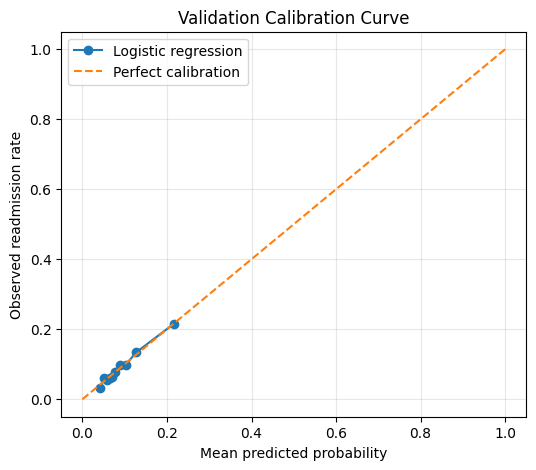

In [125]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    val_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.title("Validation Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [126]:
calibration_table = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_readmission_rate": prob_true,
})

calibration_table["difference"] = (
    calibration_table["observed_readmission_rate"]
    - calibration_table["mean_predicted_probability"]
)

display(calibration_table.round(4))

,mean_predicted_probability,observed_readmission_rate,difference
0,0.0409,0.0314,-0.0095
1,0.0514,0.0619,0.0105
2,0.0579,0.0552,-0.0027
3,0.0642,0.0620,-0.0022
4,0.0704,0.0629,-0.0075
5,0.0781,0.0781,-0.0000
6,0.0881,0.0972,0.0091
7,0.1028,0.0990,-0.0038
8,0.1274,0.1343,0.0068
9,0.2161,0.2152,-0.0009


The validation calibration curve is reasonably close to the identity line, including the highest-risk bin, although this is an internal validation check rather than evidence of external calibration.

## 3.5 Validation threshold analysis

Threshold selection is intentionally performed on validation data only. Several fixed thresholds are first shown to visualize the precision-recall tradeoff. A fine-grained precision-recall curve is then used to identify the threshold that maximizes F1.

A second operating point targets approximately **70% recall** only as an **illustrative sensitivity-oriented scenario**. Seventy percent is not treated as an academic or clinical standard; a clinically appropriate operating threshold would depend on the intervention, false-positive burden, false-negative consequences, and resource constraints.

In [127]:
thresholds = [
    0.50,
    0.30,
    0.20,
    0.15,
    0.10,
    0.08,
    0.05,
]

threshold_results = []

for threshold in thresholds:
    preds = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "predicted_positive": preds.sum(),
        "precision": precision_score(
            y_val, preds, zero_division=0
        ),
        "recall": recall_score(
            y_val, preds, zero_division=0
        ),
        "f1": f1_score(
            y_val, preds, zero_division=0
        ),
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.round(4)
)

,threshold,predicted_positive,precision,recall,f1
0,0.50,12,0.2500,0.0032,0.0063
1,0.30,109,0.3028,0.0350,0.0628
2,0.20,473,0.2347,0.1178,0.1569
3,0.15,1002,0.2176,0.2314,0.2243
4,0.10,2742,0.1575,0.4586,0.2345
5,0.08,4480,0.1335,0.6348,0.2206
6,0.05,9125,0.0975,0.9448,0.1768


In [128]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, threshold_curve = precision_recall_curve(
    y_val,
    val_prob
)

# precision_recall_curve returns one extra precision/recall value
# because the final point has no corresponding threshold.
precision_t = precision_curve[:-1]
recall_t = recall_curve[:-1]

f1_curve = (
    2 * precision_t * recall_t
    / (precision_t + recall_t + 1e-12)
)

best_idx = np.argmax(f1_curve)

best_f1_threshold = threshold_curve[best_idx]

print(f"Best validation F1 threshold: {best_f1_threshold:.4f}")
print(f"Precision: {precision_t[best_idx]:.4f}")
print(f"Recall:    {recall_t[best_idx]:.4f}")
print(f"F1:        {f1_curve[best_idx]:.4f}")

Best validation F1 threshold: 0.1168
Precision: 0.1813
Recall:    0.3737
F1:        0.2441


In [129]:
target_recall = 0.70

eligible = np.where(recall_t >= target_recall)[0]

# Among thresholds achieving at least the desired recall,
# select the one with the highest precision.
best_recall_idx = eligible[np.argmax(precision_t[eligible])]

recall_based_threshold = threshold_curve[best_recall_idx]

print(f"Target recall: {target_recall:.0%}")
print(f"Selected threshold: {recall_based_threshold:.4f}")
print(f"Precision: {precision_t[best_recall_idx]:.4f}")
print(f"Recall:    {recall_t[best_recall_idx]:.4f}")
print(f"F1:        {f1_curve[best_recall_idx]:.4f}")

Target recall: 70%
Selected threshold: 0.0736
Precision: 0.1252
Recall:    0.7049
F1:        0.2126


### Threshold findings

- The validation F1-optimal threshold is approximately **0.117**, with precision ~0.181 and recall ~0.374.
- A threshold near **0.10** was already close to the F1 optimum, illustrating that a 0.50 cutoff is poorly matched to this low-prevalence setting.
- The illustrative ~70%-recall operating point uses a threshold near **0.074**, with precision ~0.125. This catches substantially more true readmissions at the cost of flagging many more patients.

No single threshold is claimed to be clinically optimal because this dataset does not specify a downstream intervention or its relative costs and benefits.

# Phase 4 — PyTorch Multilayer Perceptron

The logistic-regression baseline is now established. This phase implements a small neural network directly in PyTorch so that the data flow, loss function, gradients, optimization, validation, and early stopping remain explicit and interview-defensible.

The model uses the same training-only preprocessing learned earlier. The test set remains untouched. CPU is sufficient for this small tabular network.


## 4.1 Reproducibility and device

We fix the random seeds used by Python, NumPy, PyTorch, and the training `DataLoader`. The project uses CPU because the processed dataset and MLP are small enough that an accelerator is unnecessary.


In [130]:
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0+cpu
Device: cpu


## 4.2 Convert the preprocessed matrices to PyTorch-ready arrays

Scikit-learn produced sparse matrices because one-hot encoding creates many zeros. With only 183 processed features, densifying them is inexpensive. Neural-network inputs and binary targets are stored as `float32`, which is the standard dtype for this model and is compatible with `BCEWithLogitsLoss`.


In [131]:
X_train_np = X_train_processed.toarray().astype(np.float32)
X_val_np = X_val_processed.toarray().astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)

print("X_train:", X_train_np.shape, X_train_np.dtype)
print("y_train:", y_train_np.shape, y_train_np.dtype)
print("X_val:  ", X_val_np.shape, X_val_np.dtype)
print("y_val:  ", y_val_np.shape, y_val_np.dtype)
print("Training feature memory:", round(X_train_np.nbytes / 1024**2, 2), "MB")


X_train: (48993, 183) float32
y_train: (48993,) float32
X_val:   (10498, 183) float32
y_val:   (10498,) float32
Training feature memory: 34.2 MB


## 4.3 Dataset and DataLoader

`ReadmissionDataset` defines how PyTorch retrieves one patient at a time: `__getitem__` returns the processed feature vector and its binary outcome. `DataLoader` then groups these observations into mini-batches. Training batches are shuffled; validation batches are not because validation performs no parameter updates.


In [132]:
class ReadmissionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = ReadmissionDataset(X_train_np, y_train_np)
val_dataset = ReadmissionDataset(X_val_np, y_val_np)

batch_size = 256

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

print("Training observations:", len(train_dataset))
print("Validation observations:", len(val_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Training observations: 48993
Validation observations: 10498
Training batches: 192
Validation batches: 42


In [133]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)
print("Positive fraction in this batch:", y_batch.mean().item())


X batch shape: torch.Size([256, 183])
y batch shape: torch.Size([256])
X dtype: torch.float32
y dtype: torch.float32
Positive fraction in this batch: 0.1015625


## 4.4 Define the MLP

The network receives all 183 processed inputs, then uses two hidden layers (64 and 32 units) with ReLU nonlinearities and 20% dropout. The final layer has one output because this is binary classification.

The network returns a **raw logit**, not a probability. During evaluation, `torch.sigmoid(logits)` converts logits to probabilities. During training, raw logits are passed directly to `BCEWithLogitsLoss`.


In [134]:
class ReadmissionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        logits = self.network(x)
        return logits.squeeze(1)


input_dim = X_train_np.shape[1]
model = ReadmissionMLP(input_dim=input_dim).to(device)

print(model)
print("Input dimension:", input_dim)


ReadmissionMLP(
  (network): Sequential(
    (0): Linear(in_features=183, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Input dimension: 183


In [135]:
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = model(X_batch)
    probabilities = torch.sigmoid(logits)

print("Input batch shape:", X_batch.shape)
print("Logits shape:", logits.shape)
print("Target shape:", y_batch.shape)
print("First 5 logits:", logits[:5])
print("First 5 probabilities:", probabilities[:5])


Input batch shape: torch.Size([256, 183])
Logits shape: torch.Size([256])
Target shape: torch.Size([256])
First 5 logits: tensor([0.2037, 0.1406, 0.2022, 0.2036, 0.2184])
First 5 probabilities: tensor([0.5508, 0.5351, 0.5504, 0.5507, 0.5544])


## 4.5 Loss and optimizer

`BCEWithLogitsLoss` combines the sigmoid transformation and binary cross-entropy calculation in a numerically stable form. It therefore consumes raw logits. Adam updates the network parameters using gradients computed by backpropagation.


In [136]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

with torch.no_grad():
    initial_logits = model(X_batch)
    initial_loss = criterion(initial_logits, y_batch)

print("Initial batch loss:", initial_loss.item())
print(optimizer)


Initial batch loss: 0.7731671333312988
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 4.6 One mini-batch training step — demonstration only

This cell demonstrates the mechanics of learning on a single mini-batch. `optimizer.zero_grad()` clears previously stored gradients, the forward pass produces logits, the loss measures error, `loss.backward()` computes gradients, and `optimizer.step()` changes the parameters.

**This is not part of the final fitted model.** The model and optimizer are freshly reinitialized immediately before the official training run below.


In [137]:
first_layer = model.network[0]
weight_before = first_layer.weight[0, 0].detach().clone()

model.train()
optimizer.zero_grad()
logits = model(X_batch)
loss = criterion(logits, y_batch)
loss.backward()
optimizer.step()

weight_after = first_layer.weight[0, 0].detach().clone()

print("Batch loss:", loss.item())
print("Weight before:", weight_before.item())
print("Weight after: ", weight_after.item())
print("Weight changed:", not torch.equal(weight_before, weight_after))
print("Gradient shape:", first_layer.weight.grad.shape)
print("Example gradient:", first_layer.weight.grad[0, 0].item())


Batch loss: 0.7740947008132935
Weight before: 0.056516315788030624
Weight after:  0.05751631036400795
Weight changed: True
Gradient shape: torch.Size([64, 183])
Example gradient: -0.0016405254136770964


## 4.7 Reusable training and validation loops

One epoch processes every mini-batch in the training set once. Training performs gradient updates; validation uses `model.eval()` and `torch.no_grad()` so dropout is disabled and no gradients or parameter updates are created. Validation probabilities are obtained by applying sigmoid to the raw logits.


In [138]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_examples = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size_actual = X_batch.size(0)
        total_loss += loss.item() * batch_size_actual
        total_examples += batch_size_actual

    return total_loss / total_examples


In [139]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_examples = 0
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            probabilities = torch.sigmoid(logits)

            batch_size_actual = X_batch.size(0)
            total_loss += loss.item() * batch_size_actual
            total_examples += batch_size_actual

            all_probabilities.append(probabilities.cpu())
            all_targets.append(y_batch.cpu())

    average_loss = total_loss / total_examples
    probabilities = torch.cat(all_probabilities).numpy()
    targets = torch.cat(all_targets).numpy()

    return average_loss, probabilities, targets


## 4.8 Final MLP training with early stopping

The final experiment starts from a **freshly initialized model and optimizer**, so the demonstration above cannot affect the fitted model.

Training runs for at most 50 epochs. We monitor validation BCE loss and use a patience of 5 epochs: if validation loss fails to improve for five consecutive epochs, training stops. The parameters from the epoch with the lowest validation loss are saved and restored. This limits overfitting while preserving the best validation-time probability model.


In [140]:
import copy

# Fresh, reproducible initialization for the official experiment.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model = ReadmissionMLP(input_dim=input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

final_train_generator = torch.Generator()
final_train_generator.manual_seed(SEED)
final_train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=final_train_generator,
)

max_epochs = 50
patience = 5
best_val_loss = float("inf")
best_model_state = None
best_epoch = None
epochs_without_improvement = 0
history = []

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(
        model, final_train_loader, criterion, optimizer, device
    )

    val_loss, epoch_val_prob, epoch_val_targets = evaluate_model(
        model, val_loader, criterion, device
    )

    epoch_roc_auc = roc_auc_score(epoch_val_targets, epoch_val_prob)
    epoch_pr_auc = average_precision_score(epoch_val_targets, epoch_val_prob)
    epoch_brier = brier_score_loss(epoch_val_targets, epoch_val_prob)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "roc_auc": epoch_roc_auc,
        "pr_auc": epoch_pr_auc,
        "brier": epoch_brier,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f} | "
        f"ROC={epoch_roc_auc:.4f} | "
        f"PR={epoch_pr_auc:.4f} | "
        f"Brier={epoch_brier:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

model.load_state_dict(best_model_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 01 | train=0.3430 | val=0.2922 | ROC=0.6511 | PR=0.1557 | Brier=0.0800
Epoch 02 | train=0.2985 | val=0.2895 | ROC=0.6608 | PR=0.1636 | Brier=0.0795
Epoch 03 | train=0.2954 | val=0.2888 | ROC=0.6586 | PR=0.1650 | Brier=0.0793
Epoch 04 | train=0.2950 | val=0.2885 | ROC=0.6605 | PR=0.1666 | Brier=0.0792
Epoch 05 | train=0.2949 | val=0.2882 | ROC=0.6617 | PR=0.1661 | Brier=0.0792
Epoch 06 | train=0.2936 | val=0.2889 | ROC=0.6560 | PR=0.1677 | Brier=0.0792
Epoch 07 | train=0.2932 | val=0.2876 | ROC=0.6625 | PR=0.1706 | Brier=0.0790
Epoch 08 | train=0.2928 | val=0.2890 | ROC=0.6614 | PR=0.1705 | Brier=0.0793
Epoch 09 | train=0.2918 | val=0.2887 | ROC=0.6590 | PR=0.1684 | Brier=0.0792
Epoch 10 | train=0.2913 | val=0.2879 | ROC=0.6614 | PR=0.1699 | Brier=0.0791
Epoch 11 | train=0.2894 | val=0.2883 | ROC=0.6595 | PR=0.1695 | Brier=0.0791
Epoch 12 | train=0.2900 | val=0.2896 | ROC=0.6608 | PR=0.1731 | Brier=0.0792

Early stopping at epoch 12.

Best epoch: 7
Best validation loss: 0.2876


## 4.9 Evaluate the restored best model

After early stopping, the saved parameters from the best validation-loss epoch are restored. We recompute validation predictions from that restored model before comparing it with logistic regression.


In [141]:
restored_val_loss, mlp_val_prob, mlp_val_targets = evaluate_model(
    model, val_loader, criterion, device
)

mlp_val_roc_auc = roc_auc_score(mlp_val_targets, mlp_val_prob)
mlp_val_pr_auc = average_precision_score(mlp_val_targets, mlp_val_prob)
mlp_val_brier = brier_score_loss(mlp_val_targets, mlp_val_prob)

print(f"Restored MLP validation loss:    {restored_val_loss:.4f}")
print(f"Restored MLP validation ROC-AUC: {mlp_val_roc_auc:.4f}")
print(f"Restored MLP validation PR-AUC:  {mlp_val_pr_auc:.4f}")
print(f"Restored MLP validation Brier:   {mlp_val_brier:.4f}")

print("\nLogistic-regression baseline:")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC:  {val_pr_auc:.4f}")
print(f"Brier:   {val_brier:.4f}")


Restored MLP validation loss:    0.2876
Restored MLP validation ROC-AUC: 0.6625
Restored MLP validation PR-AUC:  0.1706
Restored MLP validation Brier:   0.0790

Logistic-regression baseline:
ROC-AUC: 0.6555
PR-AUC:  0.1682
Brier:   0.0793


### 4.10 Learning Curves

Training and validation loss are plotted across epochs to inspect convergence
and the onset of overfitting. Validation metrics are also tracked during
training, but validation BCE loss is the predefined early-stopping criterion.

In [142]:
history_df = pd.DataFrame(history)

history_df

,epoch,train_loss,val_loss,roc_auc,pr_auc,brier
0,1,0.342965,0.292170,0.651085,0.155701,0.079969
1,2,0.298450,0.289506,0.660825,0.163649,0.079492
2,3,0.295357,0.288848,0.658580,0.165016,0.079286
3,4,0.295047,0.288484,0.660547,0.166566,0.079193
4,5,0.294907,0.288185,0.661703,0.166142,0.079154
5,6,0.293566,0.288865,0.655963,0.167718,0.079206
6,7,0.293215,0.287608,0.662541,0.170629,0.079046
7,8,0.292840,0.289004,0.661388,0.170508,0.079263
8,9,0.291751,0.288696,0.658963,0.168370,0.079164
9,10,0.291252,0.287922,0.661367,0.169922,0.079061


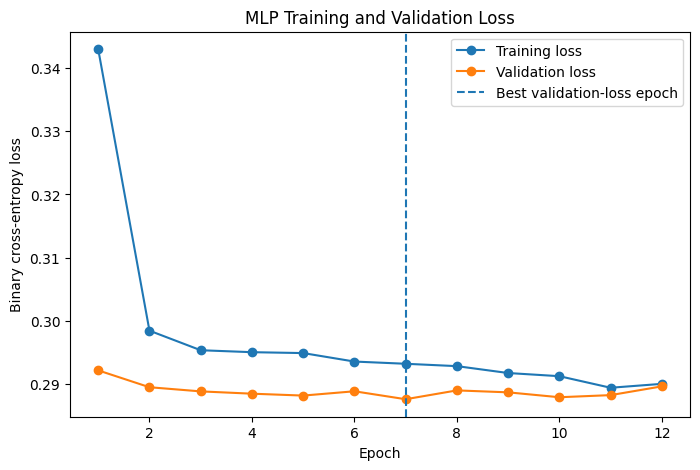

In [143]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation loss"
)

plt.axvline(
    x=history_df.loc[
        history_df["val_loss"].idxmin(),
        "epoch"
    ],
    linestyle="--",
    label="Best validation-loss epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.show()

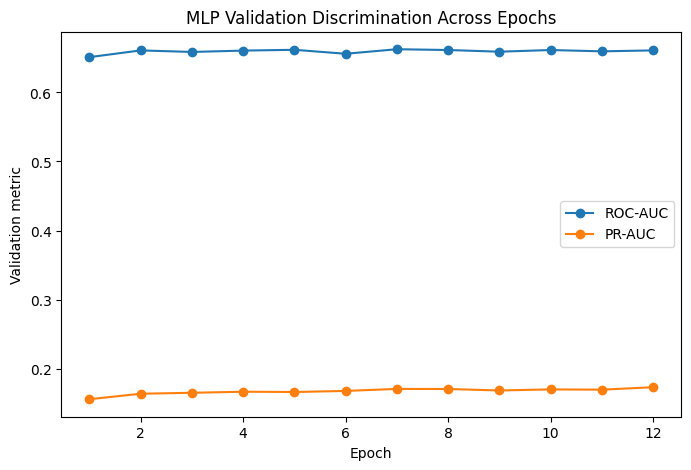

In [144]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["roc_auc"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    history_df["epoch"],
    history_df["pr_auc"],
    marker="o",
    label="PR-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("Validation metric")
plt.title("MLP Validation Discrimination Across Epochs")
plt.legend()
plt.show()

## Phase 5 — Model Comparison and Operating Characteristics

The logistic regression and MLP are compared on the validation set before
any use of the held-out test set. Comparison considers discrimination,
probability calibration, and threshold-dependent classification behavior.

### 5.1 Validation Calibration

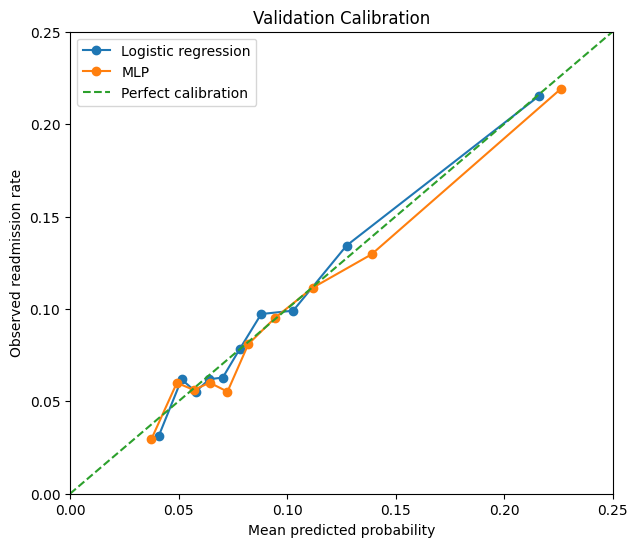

In [151]:
from sklearn.calibration import calibration_curve

log_frac_pos, log_mean_pred = calibration_curve(
    y_val,
    val_prob,
    n_bins=10,
    strategy="quantile"
)

mlp_frac_pos, mlp_mean_pred = calibration_curve(
    mlp_val_targets,
    mlp_val_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    log_mean_pred,
    log_frac_pos,
    marker="o",
    label="Logistic regression"
)

plt.plot(
    mlp_mean_pred,
    mlp_frac_pos,
    marker="o",
    label="MLP"
)

plt.plot(
    [0, 0.25],
    [0, 0.25],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlim(0, 0.25)
plt.ylim(0, 0.25)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.title("Validation Calibration")
plt.legend()
plt.show()

In [152]:
mlp_calibration_df = pd.DataFrame({
    "mean_predicted_probability": mlp_mean_pred,
    "observed_readmission_rate": mlp_frac_pos
})

mlp_calibration_df

,mean_predicted_probability,observed_readmission_rate
0,0.037486,0.029524
1,0.049232,0.060000
2,0.056995,0.056190
3,0.064371,0.060057
4,0.072561,0.055238
5,0.082159,0.080952
6,0.094622,0.095329
7,0.111783,0.111429
8,0.138936,0.129524
9,0.226158,0.219048


**Calibration interpretation.** Both models showed reasonably close agreement
between predicted and observed 30-day readmission risk across validation
probability deciles. The MLP retained calibration comparable to logistic
regression while achieving slightly higher ROC-AUC and PR-AUC and a slightly
lower Brier score. Some deviation was present in individual bins, so these
results should not be interpreted as evidence of perfect calibration.

### 5.2 MLP Threshold Analysis

ROC-AUC and PR-AUC evaluate model ranking without requiring a fixed
classification threshold. For an operational classifier, however, the
probability threshold determines the tradeoff between recall and precision.

Candidate thresholds are evaluated on the validation set only. The held-out
test set remains unused.

In [153]:
thresholds_to_check = [
    0.50,
    0.30,
    0.20,
    0.15,
    0.10,
    0.08,
    0.05,
]

mlp_threshold_rows = []

for threshold in thresholds_to_check:

    predictions = (
        mlp_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        mlp_val_targets,
        predictions
    ).ravel()

    mlp_threshold_rows.append({
        "threshold": threshold,
        "flagged": predictions.sum(),
        "precision": precision_score(
            mlp_val_targets,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            mlp_val_targets,
            predictions
        ),
        "f1": f1_score(
            mlp_val_targets,
            predictions
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    })

mlp_threshold_df = pd.DataFrame(
    mlp_threshold_rows
)

mlp_threshold_df

,threshold,flagged,precision,recall,f1,TP,FP,FN,TN
0,0.50,2,0.500000,0.001062,0.002119,1,1,941,9555
1,0.30,120,0.250000,0.031847,0.056497,30,90,912,9466
2,0.20,588,0.234694,0.146497,0.180392,138,450,804,9106
3,0.15,1245,0.209639,0.277070,0.238683,261,984,681,8572
4,0.10,3287,0.150289,0.524416,0.233625,494,2793,448,6763
5,0.08,4926,0.131750,0.688960,0.221200,649,4277,293,5279
6,0.05,8840,0.099208,0.930998,0.179309,877,7963,65,1593


In [154]:
mlp_precision_curve, mlp_recall_curve, mlp_pr_thresholds = (
    precision_recall_curve(
        mlp_val_targets,
        mlp_val_prob
    )
)

mlp_f1_curve = (
    2
    * mlp_precision_curve[:-1]
    * mlp_recall_curve[:-1]
    / (
        mlp_precision_curve[:-1]
        + mlp_recall_curve[:-1]
        + 1e-12
    )
)

best_mlp_idx = np.argmax(
    mlp_f1_curve
)

best_mlp_threshold = (
    mlp_pr_thresholds[best_mlp_idx]
)

print(
    f"Best validation F1 threshold: "
    f"{best_mlp_threshold:.4f}"
)

print(
    f"Precision: "
    f"{mlp_precision_curve[best_mlp_idx]:.4f}"
)

print(
    f"Recall: "
    f"{mlp_recall_curve[best_mlp_idx]:.4f}"
)

print(
    f"F1: "
    f"{mlp_f1_curve[best_mlp_idx]:.4f}"
)

Best validation F1 threshold: 0.1461
Precision: 0.2118
Recall: 0.3015
F1: 0.2488


In [155]:
target_recall = 0.70

eligible = (
    mlp_recall_curve[:-1] >= target_recall
)

eligible_indices = np.where(
    eligible
)[0]

best_70_idx = eligible_indices[
    np.argmax(
        mlp_precision_curve[:-1][eligible]
    )
]

mlp_70_threshold = (
    mlp_pr_thresholds[best_70_idx]
)

print(
    f"Illustrative ~70% recall threshold: "
    f"{mlp_70_threshold:.4f}"
)

print(
    f"Precision: "
    f"{mlp_precision_curve[best_70_idx]:.4f}"
)

print(
    f"Recall: "
    f"{mlp_recall_curve[best_70_idx]:.4f}"
)

print(
    f"F1: "
    f"{mlp_f1_curve[best_70_idx]:.4f}"
)

Illustrative ~70% recall threshold: 0.0774
Precision: 0.1285
Recall: 0.7091
F1: 0.2176


### 5.3 Direct Validation Comparison

The two models are compared using the same validation cohort. Threshold-free
metrics summarize discrimination and probability accuracy, while the selected
operating points compare threshold-dependent behavior.

All model and threshold decisions are finalized before evaluation on the
held-out test set.

In [156]:
model_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "MLP"
    ],
    "ROC-AUC": [
        val_roc_auc,
        mlp_val_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        mlp_val_pr_auc
    ],
    "Brier score": [
        val_brier,
        mlp_val_brier
    ]
})

model_comparison_df.round(4)

,Model,ROC-AUC,PR-AUC,Brier score
0,Logistic regression,0.6555,0.1682,0.0793
1,MLP,0.6625,0.1706,0.0790


In [157]:
operating_point_df = pd.DataFrame([
    {
        "Model": "Logistic regression",
        "Operating point": "Maximum validation F1",
        "Threshold": best_f1_threshold,
        "Precision": precision_t[best_idx],
        "Recall": recall_t[best_idx],
        "F1": f1_curve[best_idx],
    },
    {
        "Model": "MLP",
        "Operating point": "Maximum validation F1",
        "Threshold": best_mlp_threshold,
        "Precision": mlp_precision_curve[best_mlp_idx],
        "Recall": mlp_recall_curve[best_mlp_idx],
        "F1": mlp_f1_curve[best_mlp_idx],
    },
    {
        "Model": "Logistic regression",
        "Operating point": "Illustrative ~70% recall",
        "Threshold": recall_based_threshold,
        "Precision": precision_t[best_recall_idx],
        "Recall": recall_t[best_recall_idx],
        "F1": f1_curve[best_recall_idx],
    },
    {
        "Model": "MLP",
        "Operating point": "Illustrative ~70% recall",
        "Threshold": mlp_70_threshold,
        "Precision": mlp_precision_curve[best_70_idx],
        "Recall": mlp_recall_curve[best_70_idx],
        "F1": mlp_f1_curve[best_70_idx],
    },
])

operating_point_df.round(4)

,Model,Operating point,Threshold,Precision,Recall,F1
0,Logistic regression,Maximum validation F1,0.1168,0.1813,0.3737,0.2441
1,MLP,Maximum validation F1,0.1461,0.2118,0.3015,0.2488
2,Logistic regression,Illustrative ~70% recall,0.0736,0.1252,0.7049,0.2126
3,MLP,Illustrative ~70% recall,0.0774,0.1285,0.7091,0.2176


### 5.4 Model Selection

The MLP was selected as the primary final model. Its improvement over logistic
regression was modest, but consistent across validation ROC-AUC, PR-AUC, Brier
score, and the examined threshold-dependent operating points. Calibration was
also comparable between the two models.

The results therefore suggest a small benefit from nonlinear modeling rather
than a large performance gain. Logistic regression remains an important
interpretable baseline.

For final evaluation, the MLP architecture, training procedure, early-stopping
criterion, and validation-selected thresholds are now frozen. The
F1-maximizing validation threshold (approximately 0.146) will serve as the
primary binary operating point. A second threshold (approximately 0.077),
selected to illustrate a sensitivity-oriented operating point near 70% recall,
will be reported separately and should not be interpreted as a clinically
validated threshold.

No further model or threshold tuning will be performed after examining the
test set.

# Phase 6 — Final Held-Out Test Evaluation

All model-development decisions were made using the training and validation
sets. The held-out test set is now evaluated once using the already-fitted
preprocessor, frozen logistic-regression model, restored MLP weights, and
validation-selected operating thresholds.

No model, preprocessing, or threshold decisions will be changed in response
to test performance.

In [158]:
X_test_processed = preprocessor.transform(X_test)

print("Raw test shape:      ", X_test.shape)
print("Processed test shape:", X_test_processed.shape)
print("Test positives:      ", y_test.sum())
print("Test prevalence:     ", y_test.mean())

Raw test shape:       (10499, 42)
Processed test shape: (10499, 183)
Test positives:       943
Test prevalence:      0.08981807791218212


In [159]:
log_test_prob = log_reg.predict_proba(
    X_test_processed
)[:, 1]

log_test_roc_auc = roc_auc_score(
    y_test,
    log_test_prob
)

log_test_pr_auc = average_precision_score(
    y_test,
    log_test_prob
)

log_test_brier = brier_score_loss(
    y_test,
    log_test_prob
)

print("Logistic regression — TEST")
print(f"ROC-AUC: {log_test_roc_auc:.4f}")
print(f"PR-AUC:  {log_test_pr_auc:.4f}")
print(f"Brier:   {log_test_brier:.4f}")

Logistic regression — TEST
ROC-AUC: 0.6465
PR-AUC:  0.1672
Brier:   0.0794


In [160]:
X_test_np = X_test_processed.toarray().astype(np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

test_dataset = ReadmissionDataset(
    X_test_np,
    y_test_np
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loss, mlp_test_prob, mlp_test_targets = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

mlp_test_roc_auc = roc_auc_score(
    mlp_test_targets,
    mlp_test_prob
)

mlp_test_pr_auc = average_precision_score(
    mlp_test_targets,
    mlp_test_prob
)

mlp_test_brier = brier_score_loss(
    mlp_test_targets,
    mlp_test_prob
)

print("MLP — TEST")
print(f"BCE loss: {test_loss:.4f}")
print(f"ROC-AUC:  {mlp_test_roc_auc:.4f}")
print(f"PR-AUC:   {mlp_test_pr_auc:.4f}")
print(f"Brier:    {mlp_test_brier:.4f}")

MLP — TEST
BCE loss: 0.2895
ROC-AUC:  0.6480
PR-AUC:   0.1667
Brier:    0.0794


## 6.1 Frozen Operating Points on the Test Set

The probability thresholds selected using validation data are now applied
unchanged to the held-out test set. No threshold optimization is performed
using test outcomes.

In [161]:
def evaluate_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions
    ).ravel()

    return {
        "Threshold": threshold,
        "Flagged": predictions.sum(),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1": f1_score(
            y_true,
            predictions
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }

In [162]:
test_operating_points = pd.DataFrame([
    {
        "Model": "Logistic regression",
        "Operating point": "Validation-selected maximum F1",
        **evaluate_threshold(
            y_test,
            log_test_prob,
            best_f1_threshold
        )
    },
    {
        "Model": "MLP",
        "Operating point": "Validation-selected maximum F1",
        **evaluate_threshold(
            mlp_test_targets,
            mlp_test_prob,
            best_mlp_threshold
        )
    },
    {
        "Model": "Logistic regression",
        "Operating point": "Validation-selected ~70% recall",
        **evaluate_threshold(
            y_test,
            log_test_prob,
            recall_based_threshold
        )
    },
    {
        "Model": "MLP",
        "Operating point": "Validation-selected ~70% recall",
        **evaluate_threshold(
            mlp_test_targets,
            mlp_test_prob,
            mlp_70_threshold
        )
    },
])

test_operating_points.round(4)

,Model,Operating point,Threshold,Flagged,Precision,Recall,F1,TP,FP,FN,TN
0,Logistic regression,Validation-selected maximum F1,0.1168,1999,0.1626,0.3446,0.2209,325,1674,618,7882
1,MLP,Validation-selected maximum F1,0.1461,1384,0.1900,0.2789,0.2260,263,1121,680,8435
2,Logistic regression,Validation-selected ~70% recall,0.0736,5348,0.1200,0.6808,0.2041,642,4706,301,4850
3,MLP,Validation-selected ~70% recall,0.0774,5253,0.1209,0.6734,0.2050,635,4618,308,4938


### Test-set operating-point interpretation

The validation-selected thresholds transferred reasonably to the held-out test
set without further adjustment. At the maximum-F1 operating point, the MLP
achieved slightly higher precision and F1 while identifying fewer patients,
but at the cost of lower recall than logistic regression.

At the sensitivity-oriented operating point selected for approximately 70%
validation recall, both models achieved roughly 67–68% recall on the test set
with nearly identical precision and F1.

Together with the threshold-free test metrics, these results provide little
evidence that the MLP offers a practically meaningful predictive advantage
over logistic regression. The two models appear to extract similar amounts of
signal from the available feature representation.

# Phase 7 — Model Interpretation

Because logistic regression and the MLP achieved nearly identical held-out
performance, the logistic model provides a useful interpretable view of the
predictive signal available in the feature representation.

Interpretation here is descriptive rather than causal. Coefficients indicate
how the fitted model uses features conditional on the other included
predictors; they do not establish that a feature causes readmission.

Categorical predictors were one-hot encoded without dropping a reference
level. Their coefficients are therefore inspected as model weights rather
than interpreted as conventional reference-category odds ratios.

In [164]:
logistic_coef_df = pd.DataFrame({
    "feature": processed_feature_names,
    "coefficient": log_reg.coef_.ravel()
})

logistic_coef_df["abs_coefficient"] = (
    logistic_coef_df["coefficient"].abs()
)

print("Number of coefficients:", len(logistic_coef_df))

logistic_coef_df.head()

Number of coefficients: 183


,feature,coefficient,abs_coefficient
0,num__time_in_hospital,0.050732,0.050732
1,num__num_lab_procedures,0.024517,0.024517
2,num__num_procedures,-0.004041,0.004041
3,num__num_medications,0.002257,0.002257
4,num__number_outpatient,-0.000075,0.000075


In [165]:
top_positive = (
    logistic_coef_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(15)
)

top_positive[
    ["feature", "coefficient"]
]

,feature,coefficient
46,cat__discharge_disposition_id_15,1.411401
55,cat__discharge_disposition_id_28,1.290869
50,cat__discharge_disposition_id_22,0.856364
123,cat__repaglinide_Up,0.733786
39,cat__discharge_disposition_id_5,0.640802
58,cat__admission_source_id_3,0.639075
95,cat__diag_2_group_Neoplasms,0.422644
64,cat__admission_source_id_9,0.410603
69,cat__admission_source_id_20,0.332004
83,cat__diag_1_group_Missing,0.323298


In [166]:
top_negative = (
    logistic_coef_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(15)
)

top_negative[
    ["feature", "coefficient"]
]

,feature,coefficient
51,cat__discharge_disposition_id_23,-1.814597
53,cat__discharge_disposition_id_25,-0.880964
35,cat__discharge_disposition_id_1,-0.646940
93,cat__diag_2_group_Missing,-0.480202
60,cat__admission_source_id_5,-0.478482
120,cat__repaglinide_Down,-0.466546
17,cat__age_[0-10),-0.419127
166,cat__tolazamide_Steady,-0.415476
121,cat__repaglinide_No,-0.404126
40,cat__discharge_disposition_id_6,-0.393371


In [167]:
categorical_mask = (
    logistic_coef_df["feature"]
    .str.startswith("cat__")
)

categorical_indices = np.where(
    categorical_mask
)[0]

categorical_counts = np.asarray(
    X_train_processed[
        :,
        categorical_indices
    ].sum(axis=0)
).ravel()

logistic_coef_df.loc[
    categorical_mask,
    "train_count"
] = categorical_counts

logistic_coef_df.loc[
    categorical_mask,
    "train_percent"
] = (
    categorical_counts
    / X_train_processed.shape[0]
    * 100
)

In [168]:
top_positive = (
    logistic_coef_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(15)
)

top_positive[
    [
        "feature",
        "coefficient",
        "train_count",
        "train_percent"
    ]
].round(4)

,feature,coefficient,train_count,train_percent
46,cat__discharge_disposition_id_15,1.4114,26.0,0.0531
55,cat__discharge_disposition_id_28,1.2909,55.0,0.1123
50,cat__discharge_disposition_id_22,0.8564,994.0,2.0289
123,cat__repaglinide_Up,0.7338,51.0,0.1041
39,cat__discharge_disposition_id_5,0.6408,632.0,1.2900
58,cat__admission_source_id_3,0.6391,93.0,0.1898
95,cat__diag_2_group_Neoplasms,0.4226,1104.0,2.2534
64,cat__admission_source_id_9,0.4106,63.0,0.1286
69,cat__admission_source_id_20,0.3320,111.0,0.2266
83,cat__diag_1_group_Missing,0.3233,7.0,0.0143


In [169]:
top_negative = (
    logistic_coef_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(15)
)

top_negative[
    [
        "feature",
        "coefficient",
        "train_count",
        "train_percent"
    ]
].round(4)

,feature,coefficient,train_count,train_percent
51,cat__discharge_disposition_id_23,-1.8146,172.0,0.3511
53,cat__discharge_disposition_id_25,-0.8810,543.0,1.1083
35,cat__discharge_disposition_id_1,-0.6469,31009.0,63.2927
93,cat__diag_2_group_Missing,-0.4802,218.0,0.4450
60,cat__admission_source_id_5,-0.4785,365.0,0.7450
120,cat__repaglinide_Down,-0.4665,17.0,0.0347
17,cat__age_[0-10),-0.4191,111.0,0.2266
166,cat__tolazamide_Steady,-0.4155,21.0,0.0429
121,cat__repaglinide_No,-0.4041,48336.0,98.6590
40,cat__discharge_disposition_id_6,-0.3934,5806.0,11.8507


In [170]:
numeric_coef_df = (
    logistic_coef_df[
        logistic_coef_df["feature"]
        .str.startswith("num__")
    ]
    .sort_values(
        "coefficient",
        ascending=False
    )
)

numeric_coef_df[
    ["feature", "coefficient"]
]

,feature,coefficient
6,num__number_inpatient,0.198613
7,num__number_diagnoses,0.065381
0,num__time_in_hospital,0.050732
5,num__number_emergency,0.046350
1,num__num_lab_procedures,0.024517
3,num__num_medications,0.002257
4,num__number_outpatient,-0.000075
2,num__num_procedures,-0.004041


### Logistic-coefficient interpretation

The largest raw categorical coefficients were often associated with rare
levels, including medication-change states and uncommon administrative
disposition codes. Large coefficients for such levels may be unstable and
should not be interpreted as evidence that they are major population-level
predictors.

Among the standardized numeric predictors, prior inpatient utilization
(`number_inpatient`) had the largest positive coefficient, followed by
`number_diagnoses`, `time_in_hospital`, and `number_emergency`. This suggests
that prior healthcare utilization and encounter complexity contribute more
consistently to the model's predicted readmission risk than most other
continuous/count features.

Because categorical variables were fully one-hot encoded without an omitted
reference level, individual dummy-variable coefficients are treated as
descriptive model weights rather than conventional reference-category effect
estimates. All interpretations are predictive associations and not causal
effects.

In [171]:
common_categorical_coef_df = (
    logistic_coef_df[
        logistic_coef_df["feature"].str.startswith("cat__")
        & (logistic_coef_df["train_percent"] >= 1.0)
    ]
    .copy()
)

common_positive = (
    common_categorical_coef_df
    .sort_values("coefficient", ascending=False)
    .head(15)
)

common_negative = (
    common_categorical_coef_df
    .sort_values("coefficient", ascending=True)
    .head(15)
)

print("Strongest positive weights among categories with >=1% training support:")
display(
    common_positive[
        ["feature", "coefficient", "train_count", "train_percent"]
    ].round(4)
)

print("\nStrongest negative weights among categories with >=1% training support:")
display(
    common_negative[
        ["feature", "coefficient", "train_count", "train_percent"]
    ].round(4)
)

Strongest positive weights among categories with >=1% training support:


,feature,coefficient,train_count,train_percent
50,cat__discharge_disposition_id_22,0.8564,994.0,2.0289
39,cat__discharge_disposition_id_5,0.6408,632.0,1.2900
95,cat__diag_2_group_Neoplasms,0.4226,1104.0,2.2534
32,cat__admission_type_id_6,0.2750,3143.0,6.4152
165,cat__tolazamide_No,0.2167,48972.0,99.9571
24,cat__age_[70-80),0.1610,12445.0,25.4016
125,cat__nateglinide_No,0.1584,48641.0,99.2815
100,cat__diag_3_group_Digestive,0.1499,1876.0,3.8291
89,cat__diag_2_group_Diabetes,0.1496,6768.0,13.8142
23,cat__age_[60-70),0.1412,10966.0,22.3828



Strongest negative weights among categories with >=1% training support:


,feature,coefficient,train_count,train_percent
53,cat__discharge_disposition_id_25,-0.8810,543.0,1.1083
35,cat__discharge_disposition_id_1,-0.6469,31009.0,63.2927
121,cat__repaglinide_No,-0.4041,48336.0,98.6590
40,cat__discharge_disposition_id_6,-0.3934,5806.0,11.8507
119,cat__metformin_Up,-0.3072,589.0,1.2022
68,cat__admission_source_id_17,-0.2520,3375.0,6.8887
84,cat__diag_1_group_Musculoskeletal,-0.2468,2843.0,5.8029
59,cat__admission_source_id_4,-0.2245,1757.0,3.5862
72,cat__medical_specialty_group_Cardiology,-0.2195,2897.0,5.9131
134,cat__glimepiride_Steady,-0.2129,2285.0,4.6639


### Coefficient summary

After excluding very rare categorical levels from the displayed rankings,
discharge-disposition categories remained prominent, while older age groups
and several diagnosis groups also received positive model weights. Among the
standardized numeric predictors, prior inpatient utilization was the strongest
positive coefficient.

Individual one-hot coefficients are not treated as feature-importance
estimates. Several medication indicators were nearly or completely constant,
and the full one-hot representation introduces redundancy among category
levels. The coefficient analysis is therefore used only as a descriptive view
of the fitted linear model.

### 7.4 Permutation Importance

Permutation importance evaluates predictors at the original feature level
rather than at the individual one-hot-column level. Each validation feature is
randomly shuffled while all other predictors remain unchanged. The resulting
decrease in model performance estimates how strongly the fitted model depends
on information contained in that feature.

Importance is measured using both ROC-AUC and average precision. Five
independent permutations are used per feature to reduce sensitivity to any
single random shuffle.

These values describe predictive importance to the fitted model and should
not be interpreted causally.

In [172]:
rng = np.random.default_rng(42)

n_repeats = 5

baseline_roc = roc_auc_score(
    y_val,
    val_prob
)

baseline_ap = average_precision_score(
    y_val,
    val_prob
)

baseline_brier = brier_score_loss(
    y_val,
    val_prob
)

permutation_rows = []

for i, feature in enumerate(model_features, start=1):

    roc_drops = []
    ap_drops = []
    brier_increases = []

    for _ in range(n_repeats):

        X_permuted = X_val.copy()

        X_permuted[feature] = rng.permutation(
            X_permuted[feature].to_numpy()
        )

        X_permuted_processed = preprocessor.transform(
            X_permuted
        )

        permuted_prob = log_reg.predict_proba(
            X_permuted_processed
        )[:, 1]

        permuted_roc = roc_auc_score(
            y_val,
            permuted_prob
        )

        permuted_ap = average_precision_score(
            y_val,
            permuted_prob
        )

        permuted_brier = brier_score_loss(
            y_val,
            permuted_prob
        )

        roc_drops.append(
            baseline_roc - permuted_roc
        )

        ap_drops.append(
            baseline_ap - permuted_ap
        )

        brier_increases.append(
            permuted_brier - baseline_brier
        )

    permutation_rows.append({
        "feature": feature,
        "roc_auc_drop_mean": np.mean(roc_drops),
        "roc_auc_drop_std": np.std(roc_drops),
        "pr_auc_drop_mean": np.mean(ap_drops),
        "pr_auc_drop_std": np.std(ap_drops),
        "brier_increase_mean": np.mean(brier_increases),
    })

    if i % 10 == 0 or i == len(model_features):
        print(
            f"Completed {i}/{len(model_features)} features"
        )

permutation_importance_df = pd.DataFrame(
    permutation_rows
)

Completed 10/42 features
Completed 20/42 features
Completed 30/42 features
Completed 40/42 features
Completed 42/42 features


In [173]:
top_permutation_features = (
    permutation_importance_df
    .sort_values(
        "roc_auc_drop_mean",
        ascending=False
    )
    .head(15)
)

top_permutation_features.round(4)

,feature,roc_auc_drop_mean,roc_auc_drop_std,pr_auc_drop_mean,pr_auc_drop_std,brier_increase_mean
12,discharge_disposition_id,0.0720,0.0040,0.0466,0.0012,0.0026
6,number_inpatient,0.0267,0.0024,0.0253,0.0023,0.0013
10,age,0.0111,0.0013,0.0035,0.0005,0.0002
7,number_diagnoses,0.0060,0.0017,0.0009,0.0006,0.0001
15,diag_1_group,0.0052,0.0017,0.0040,0.0009,0.0002
41,diabetesMed,0.0039,0.0015,0.0009,0.0009,0.0000
16,diag_2_group,0.0036,0.0017,0.0038,0.0010,0.0001
11,admission_type_id,0.0031,0.0008,0.0014,0.0007,0.0001
13,admission_source_id,0.0029,0.0012,0.0022,0.0004,0.0001
0,time_in_hospital,0.0020,0.0009,0.0015,0.0006,0.0001


### Permutation-importance findings

Permutation importance identified discharge disposition as the strongest
predictor used by the logistic-regression model. Shuffling
`discharge_disposition_id` reduced validation ROC-AUC by approximately 0.072
and average precision by approximately 0.047, substantially more than any
other predictor.

Prior inpatient utilization (`number_inpatient`) was the second most important
feature, with a mean ROC-AUC decrease of approximately 0.027 and a comparable
decrease in average precision. This agrees with the coefficient analysis, in
which prior inpatient utilization was the strongest standardized numeric
predictor.

Age, diagnosis burden, diagnosis groups, and admission characteristics
provided smaller additional contributions. Most medication indicators and
other encounter-count variables showed little unique permutation importance
once the remaining predictors were available.

Because the prediction time was defined as hospital discharge, discharge
disposition is an eligible predictor in this analysis. Its dominant importance
also means that the resulting model should not be interpreted as an
admission-time or early-hospitalization risk model. Permutation importance
describes dependence of the fitted predictive model and does not establish
causal effects.

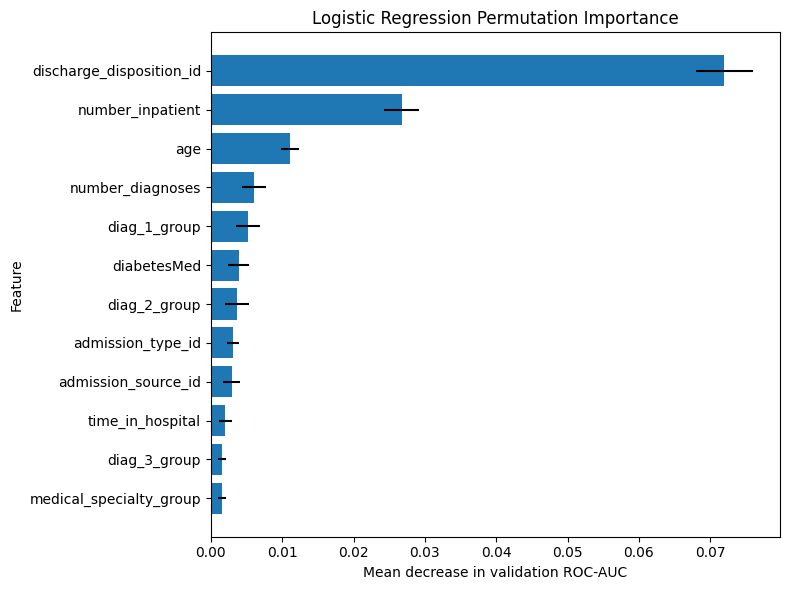

In [174]:
plot_importance = (
    permutation_importance_df
    .sort_values(
        "roc_auc_drop_mean",
        ascending=False
    )
    .head(12)
    .sort_values(
        "roc_auc_drop_mean",
        ascending=True
    )
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_importance["feature"],
    plot_importance["roc_auc_drop_mean"],
    xerr=plot_importance["roc_auc_drop_std"]
)

plt.xlabel("Mean decrease in validation ROC-AUC")
plt.ylabel("Feature")
plt.title("Logistic Regression Permutation Importance")

plt.tight_layout()
plt.show()

### 7.5 MLP Permutation Importance

The same original-feature permutation analysis is repeated for the MLP to
determine whether the nonlinear model relies on a meaningfully different set
of predictors from logistic regression.

The analysis again uses only the validation set. Features are permuted using
the same random seed and number of repetitions as the logistic-regression
analysis.

In [175]:
def predict_mlp_from_raw(X_raw):
    X_processed = preprocessor.transform(
        X_raw
    )

    X_np = (
        X_processed
        .toarray()
        .astype(np.float32)
    )

    X_tensor = torch.from_numpy(
        X_np
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_tensor)

        probabilities = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
        )

    return probabilities

In [176]:
mlp_val_prob_check = predict_mlp_from_raw(
    X_val
)

print(
    "Maximum probability difference:",
    np.max(
        np.abs(
            mlp_val_prob_check
            - mlp_val_prob
        )
    )
)

Maximum probability difference: 3.7252903e-08


In [178]:
rng = np.random.default_rng(42)

n_repeats = 5

mlp_baseline_roc = roc_auc_score(
    mlp_val_targets,
    mlp_val_prob
)

mlp_baseline_ap = average_precision_score(
    mlp_val_targets,
    mlp_val_prob
)

mlp_baseline_brier = brier_score_loss(
    mlp_val_targets,
    mlp_val_prob
)

mlp_permutation_rows = []

for i, feature in enumerate(model_features, start=1):

    roc_drops = []
    ap_drops = []
    brier_increases = []

    for _ in range(n_repeats):

        X_permuted = X_val.copy()

        X_permuted[feature] = rng.permutation(
            X_permuted[feature].to_numpy()
        )

        permuted_prob = predict_mlp_from_raw(
            X_permuted
        )

        permuted_roc = roc_auc_score(
            y_val,
            permuted_prob
        )

        permuted_ap = average_precision_score(
            y_val,
            permuted_prob
        )

        permuted_brier = brier_score_loss(
            y_val,
            permuted_prob
        )

        roc_drops.append(
            mlp_baseline_roc - permuted_roc
        )

        ap_drops.append(
            mlp_baseline_ap - permuted_ap
        )

        brier_increases.append(
            permuted_brier - mlp_baseline_brier
        )

    mlp_permutation_rows.append({
        "feature": feature,
        "roc_auc_drop_mean": np.mean(roc_drops),
        "roc_auc_drop_std": np.std(roc_drops),
        "pr_auc_drop_mean": np.mean(ap_drops),
        "pr_auc_drop_std": np.std(ap_drops),
        "brier_increase_mean": np.mean(brier_increases),
    })

    if i % 10 == 0 or i == len(model_features):
        print(
            f"Completed {i}/{len(model_features)} features"
        )

mlp_permutation_importance_df = pd.DataFrame(
    mlp_permutation_rows
)

Completed 10/42 features
Completed 20/42 features
Completed 30/42 features
Completed 40/42 features
Completed 42/42 features


In [179]:
top_mlp_permutation_features = (
    mlp_permutation_importance_df
    .sort_values(
        "roc_auc_drop_mean",
        ascending=False
    )
    .head(15)
)

top_mlp_permutation_features.round(4)

,feature,roc_auc_drop_mean,roc_auc_drop_std,pr_auc_drop_mean,pr_auc_drop_std,brier_increase_mean
12,discharge_disposition_id,0.0694,0.0036,0.0407,0.0017,0.0026
6,number_inpatient,0.0292,0.0030,0.0318,0.0027,0.0017
10,age,0.0087,0.0009,0.0023,0.0008,0.0002
15,diag_1_group,0.0064,0.0015,0.0034,0.0008,0.0002
41,diabetesMed,0.0047,0.0013,0.0013,0.0005,0.0001
16,diag_2_group,0.0047,0.0015,0.0027,0.0006,0.0002
0,time_in_hospital,0.0044,0.0013,0.0018,0.0006,0.0001
7,number_diagnoses,0.0038,0.0009,0.0008,0.0003,0.0001
5,number_emergency,0.0027,0.0019,0.0005,0.0011,0.0001
13,admission_source_id,0.0023,0.0009,0.0001,0.0005,0.0001


### MLP permutation-importance findings

The MLP showed a feature-importance pattern closely aligned with logistic
regression. Discharge disposition was again the dominant predictor, followed
by prior inpatient utilization (`number_inpatient`). Age and diagnosis-group
variables contributed smaller amounts of predictive information.

The agreement between the two model classes is notable because they achieved
nearly identical held-out predictive performance while relying on broadly the
same features. This suggests that the limited incremental performance of the
MLP was not due to learning a substantially different feature representation;
rather, both models appear to extract similar signal from the available
tabular predictors.

As with the logistic-regression analysis, permutation importance reflects
predictive dependence and should not be interpreted causally.

In [180]:
importance_comparison_df = (
    permutation_importance_df[
        ["feature", "roc_auc_drop_mean"]
    ]
    .rename(
        columns={
            "roc_auc_drop_mean":
            "logistic_roc_drop"
        }
    )
    .merge(
        mlp_permutation_importance_df[
            ["feature", "roc_auc_drop_mean"]
        ].rename(
            columns={
                "roc_auc_drop_mean":
                "mlp_roc_drop"
            }
        ),
        on="feature"
    )
)

importance_comparison_df[
    "mean_importance"
] = (
    importance_comparison_df[
        ["logistic_roc_drop", "mlp_roc_drop"]
    ]
    .mean(axis=1)
)

importance_comparison_df = (
    importance_comparison_df
    .sort_values(
        "mean_importance",
        ascending=False
    )
)

importance_comparison_df.head(15).round(4)

,feature,logistic_roc_drop,mlp_roc_drop,mean_importance
12,discharge_disposition_id,0.0720,0.0694,0.0707
6,number_inpatient,0.0267,0.0292,0.0280
10,age,0.0111,0.0087,0.0099
15,diag_1_group,0.0052,0.0064,0.0058
7,number_diagnoses,0.0060,0.0038,0.0049
41,diabetesMed,0.0039,0.0047,0.0043
16,diag_2_group,0.0036,0.0047,0.0042
0,time_in_hospital,0.0020,0.0044,0.0032
13,admission_source_id,0.0029,0.0023,0.0026
11,admission_type_id,0.0031,0.0017,0.0024


In [181]:
from scipy.stats import spearmanr

importance_rank_corr, importance_rank_p = spearmanr(
    importance_comparison_df["logistic_roc_drop"],
    importance_comparison_df["mlp_roc_drop"]
)

print(
    f"Spearman rank correlation: "
    f"{importance_rank_corr:.3f}"
)

Spearman rank correlation: 0.935


### Cross-model agreement in feature importance

Permutation-importance rankings were highly consistent between logistic
regression and the MLP. Across the original 42 predictors, the Spearman rank
correlation between model-specific ROC-AUC permutation importance values was
0.935.

Both models identified discharge disposition as the dominant predictor,
followed by prior inpatient utilization and age. Diagnosis-related variables
provided smaller secondary contributions.

The strong agreement in feature rankings, combined with nearly identical
held-out predictive performance, suggests that the MLP did not uncover a
substantially different source of predictive signal from the logistic model.
For this feature representation and cohort, increased model complexity offered
little practical advantage.

# Phase 8 — Conclusions and Limitations

## 8.1 Main Findings

This project evaluated 30-day hospital readmission prediction in a cohort of
approximately 70,000 unique patients from the UCI Diabetes 130-US Hospitals
dataset.

A regularized logistic regression and a small PyTorch multilayer perceptron
were developed using the same 42 discharge-time predictors and the same
training, validation, and held-out test partitions.

Both models achieved modest discrimination. The MLP showed a small advantage
during validation, but this difference did not translate into a meaningful
improvement on the held-out test set. Test ROC-AUC was approximately 0.65 for
both models, with similarly close average precision and Brier scores.

These results suggest that, for this feature representation, increased model
complexity provided little practical predictive benefit over logistic
regression.

## 8.2 Threshold and Calibration Findings

The low prevalence of 30-day readmission made a default probability threshold
of 0.50 unsuitable for identifying most positive cases.

Thresholds were therefore selected using validation data before the test set
was evaluated. The validation-selected maximum-F1 operating points produced
test F1 scores of approximately 0.22 for both models. A second illustrative
operating point targeting roughly 70% validation recall transferred to
approximately 67–68% recall on the held-out test set.

These thresholds are presented as examples of different precision-recall
tradeoffs rather than clinically validated decision rules. A clinically
appropriate operating point would depend on the downstream intervention,
available resources, and the relative consequences of false-positive and
false-negative classifications.

Both models also showed reasonably close agreement between predicted and
observed risks on validation calibration analyses, with similar Brier scores.

## 8.3 Predictive Signal and Model Interpretation

Permutation importance showed that both models relied on highly similar
sources of predictive information.

Discharge disposition was the dominant predictor, followed by prior inpatient
utilization (`number_inpatient`). Age and diagnosis-related variables provided
smaller secondary contributions.

The agreement was not limited to the most important features. Across all 42
original predictors, logistic-regression and MLP permutation-importance
rankings had a Spearman correlation of approximately 0.94.

Together with their nearly identical held-out performance, this suggests that
the MLP did not uncover a substantially different source of predictive signal.
Both models appear to extract largely the same information from the available
tabular features.

## 8.4 Limitations

Several limitations affect the interpretation and generalizability of this
analysis.

**Prediction time.** The prediction problem was explicitly defined at hospital
discharge. Features known by discharge, including discharge disposition and
length of stay, were therefore eligible predictors. Because discharge
disposition was the most important feature in both models, these results
should not be interpreted as the performance of an admission-time or
early-hospitalization risk model.

**Historical observational data.** The dataset contains encounters from
1999–2008. Clinical practice, coding systems, treatment patterns, and
readmission-management strategies have changed substantially since that
period. Performance should therefore not be assumed to transfer directly to
modern hospital populations.

**Public-release chronology.** The public UCI release does not provide a
documented timestamp suitable for constructing a reliable temporal validation
split. Random stratified train, validation, and test partitions were therefore
used after restricting the cohort to one qualifying encounter per patient.
This prevents direct patient overlap between partitions but does not reproduce
prospective temporal deployment.

**Residual dependence and site effects.** Restricting the cohort to one
encounter per patient removes repeated observations from the same patient, but
observations may still share hospital-level or other unmeasured structure.
Hospital identifiers were not available for site-stratified validation.

**Feature representation.** Diagnosis codes and medical specialties were
grouped into broader categories to reduce dimensionality and sparsity. This
improves modeling practicality but discards some clinical detail.

**Interpretation.** Logistic coefficients and permutation importance describe
predictive associations and model dependence rather than causal effects.
Correlated or redundant predictors can also divide permutation importance
between related variables.

**Moderate predictive performance.** Neither model achieved strong
discrimination. The results indicate that the available structured variables
contain useful but limited information for predicting 30-day readmission.

## 8.5 Future Work

Several extensions could build on this analysis:

- evaluate the models on a newer external hospital cohort;
- construct a prospective temporal validation design if trustworthy encounter
  dates become available;
- compare performance across hospitals or demographic subgroups when reliable
  site information is available;
- evaluate an earlier prediction time using only information available at
  admission;
- investigate richer diagnosis representations or learned categorical
  embeddings;
- compare additional tabular model classes, such as gradient-boosted decision
  trees;
- evaluate clinical utility using a specified intervention and explicit
  false-positive and false-negative costs.

The current results establish a reproducible baseline and show that a small
neural network did not materially outperform a well-specified logistic model
for this cohort and feature set.

## Final Takeaway

For discharge-time prediction of 30-day readmission in this cohort, logistic
regression and a small PyTorch MLP generalized almost identically. Both relied
most heavily on discharge disposition and prior inpatient utilization, and
their feature-importance rankings were highly concordant.

The central finding is therefore not that a more complex model produced a
large improvement, but that model complexity added little beyond the signal
already captured by a regularized linear baseline.

# Exploratory Extension — XGBoost

After completion of the prespecified logistic-regression and PyTorch MLP
analysis, a gradient-boosted tree model was added as a post-hoc exploratory
benchmark.

This extension uses the exact same cohort, 42 original predictors,
train/validation/test partition, and training-fitted preprocessing pipeline as
the original models. XGBoost therefore receives the same 183-dimensional
processed feature representation.

To preserve an apples-to-apples comparison:

- XGBoost is fitted using the training set only;
- the validation set is used for early stopping and threshold selection;
- the existing test set is not used for model fitting, hyperparameter
  selection, or threshold selection;
- no class weighting is used in the initial experiment;
- all XGBoost decisions are frozen before XGBoost test predictions are
  generated.

Because this model was conceived after the original test results had already
been inspected, its comparison is considered exploratory rather than an
independent confirmatory test.

In [183]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [184]:
dtrain = xgb.DMatrix(
    X_train_processed,
    label=y_train.to_numpy()
)

dval = xgb.DMatrix(
    X_val_processed,
    label=y_val.to_numpy()
)

print("Training rows:", dtrain.num_row())
print("Validation rows:", dval.num_row())
print("Features:", dtrain.num_col())

Training rows: 48993
Validation rows: 10498
Features: 183


In [185]:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",

    "eta": 0.03,
    "max_depth": 3,

    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,

    "lambda": 1.0,
    "alpha": 0.0,

    "tree_method": "hist",
    "seed": 42,
}

num_boost_round = 2000
early_stopping_rounds = 50

In [186]:
xgb_evals_result = {}

xgb_model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=[
        (dtrain, "train"),
        (dval, "validation"),
    ],
    early_stopping_rounds=early_stopping_rounds,
    evals_result=xgb_evals_result,
    verbose_eval=25,
)

print()
print("Best iteration:", xgb_model.best_iteration)
print("Best validation log loss:", xgb_model.best_score)

[0]	train-logloss:0.30154	validation-logloss:0.30137
[25]	train-logloss:0.29392	validation-logloss:0.29401
[50]	train-logloss:0.29121	validation-logloss:0.29149
[75]	train-logloss:0.28972	validation-logloss:0.29035
[100]	train-logloss:0.28855	validation-logloss:0.28953
[125]	train-logloss:0.28767	validation-logloss:0.28906
[150]	train-logloss:0.28673	validation-logloss:0.28834
[175]	train-logloss:0.28600	validation-logloss:0.28812
[200]	train-logloss:0.28540	validation-logloss:0.28785
[225]	train-logloss:0.28476	validation-logloss:0.28748
[250]	train-logloss:0.28424	validation-logloss:0.28743
[275]	train-logloss:0.28368	validation-logloss:0.28728
[300]	train-logloss:0.28324	validation-logloss:0.28720
[325]	train-logloss:0.28280	validation-logloss:0.28710
[350]	train-logloss:0.28235	validation-logloss:0.28700
[375]	train-logloss:0.28189	validation-logloss:0.28695
[400]	train-logloss:0.28140	validation-logloss:0.28687
[425]	train-logloss:0.28097	validation-logloss:0.28679
[450]	train-log

In [187]:
xgb_val_prob = xgb_model.predict(
    dval,
    iteration_range=(
        0,
        xgb_model.best_iteration + 1
    )
)

In [188]:
xgb_val_roc_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

xgb_val_pr_auc = average_precision_score(
    y_val,
    xgb_val_prob
)

xgb_val_brier = brier_score_loss(
    y_val,
    xgb_val_prob
)

print("XGBoost — VALIDATION")
print(f"ROC-AUC: {xgb_val_roc_auc:.4f}")
print(f"PR-AUC:  {xgb_val_pr_auc:.4f}")
print(f"Brier:   {xgb_val_brier:.4f}")

XGBoost — VALIDATION
ROC-AUC: 0.6646
PR-AUC:  0.1836
Brier:   0.0786


## XGBoost Validation Calibration

Calibration is evaluated on the validation set before any XGBoost test
predictions are generated.

In [190]:
from sklearn.calibration import calibration_curve

xgb_frac_pos, xgb_mean_pred = calibration_curve(
    y_val,
    xgb_val_prob,
    n_bins=10,
    strategy="quantile"
)

xgb_calibration_df = pd.DataFrame({
    "mean_predicted_probability": xgb_mean_pred,
    "observed_fraction_positive": xgb_frac_pos
})

xgb_calibration_df.round(4)

,mean_predicted_probability,observed_fraction_positive
0,0.0403,0.0371
1,0.0504,0.0457
2,0.0571,0.0600
3,0.0637,0.0562
4,0.0714,0.0733
5,0.0800,0.0724
6,0.0912,0.0867
7,0.1056,0.1048
8,0.1265,0.1333
9,0.2093,0.2276


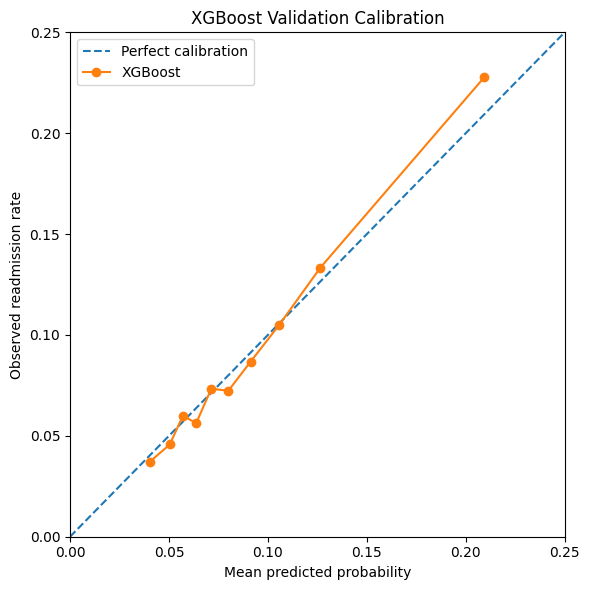

In [191]:
plt.figure(figsize=(6, 6))

plt.plot(
    [0, 0.25],
    [0, 0.25],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    xgb_mean_pred,
    xgb_frac_pos,
    marker="o",
    label="XGBoost"
)

plt.xlim(0, 0.25)
plt.ylim(0, 0.25)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.title("XGBoost Validation Calibration")
plt.legend()

plt.tight_layout()
plt.show()

## XGBoost Validation Threshold Selection

Thresholds are selected using validation predictions only. These thresholds
will be applied unchanged to the existing held-out test set.

In [192]:
xgb_precision_curve, xgb_recall_curve, xgb_thresholds = (
    precision_recall_curve(
        y_val,
        xgb_val_prob
    )
)

xgb_precision_t = xgb_precision_curve[:-1]
xgb_recall_t = xgb_recall_curve[:-1]

xgb_f1_curve = (
    2
    * xgb_precision_t
    * xgb_recall_t
    / (
        xgb_precision_t
        + xgb_recall_t
        + 1e-12
    )
)

best_xgb_idx = np.argmax(
    xgb_f1_curve
)

best_xgb_threshold = (
    xgb_thresholds[best_xgb_idx]
)

print(
    f"Best validation F1 threshold: "
    f"{best_xgb_threshold:.4f}"
)

print(
    f"Precision: "
    f"{xgb_precision_t[best_xgb_idx]:.4f}"
)

print(
    f"Recall: "
    f"{xgb_recall_t[best_xgb_idx]:.4f}"
)

print(
    f"F1: "
    f"{xgb_f1_curve[best_xgb_idx]:.4f}"
)

Best validation F1 threshold: 0.1186
Precision: 0.1884
Recall: 0.3790
F1: 0.2517


In [193]:
target_recall = 0.70

eligible = (
    xgb_recall_t >= target_recall
)

eligible_indices = np.where(
    eligible
)[0]

best_xgb_70_idx = eligible_indices[
    np.argmax(
        xgb_precision_t[eligible]
    )
]

xgb_70_threshold = (
    xgb_thresholds[best_xgb_70_idx]
)

print(
    f"Illustrative ~70% recall threshold: "
    f"{xgb_70_threshold:.4f}"
)

print(
    f"Precision: "
    f"{xgb_precision_t[best_xgb_70_idx]:.4f}"
)

print(
    f"Recall: "
    f"{xgb_recall_t[best_xgb_70_idx]:.4f}"
)

print(
    f"F1: "
    f"{xgb_f1_curve[best_xgb_70_idx]:.4f}"
)

Illustrative ~70% recall threshold: 0.0750
Precision: 0.1245
Recall: 0.7006
F1: 0.2114


In [194]:
three_model_validation_df = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "MLP",
        "XGBoost"
    ],
    "ROC-AUC": [
        val_roc_auc,
        mlp_val_roc_auc,
        xgb_val_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        mlp_val_pr_auc,
        xgb_val_pr_auc
    ],
    "Brier score": [
        val_brier,
        mlp_val_brier,
        xgb_val_brier
    ]
})

three_model_validation_df.round(4)

,Model,ROC-AUC,PR-AUC,Brier score
0,Logistic regression,0.6555,0.1682,0.0793
1,MLP,0.6625,0.1706,0.0790
2,XGBoost,0.6646,0.1836,0.0786


In [195]:
dtest = xgb.DMatrix(
    X_test_processed,
    label=y_test.to_numpy()
)

xgb_test_prob = xgb_model.predict(
    dtest,
    iteration_range=(
        0,
        xgb_model.best_iteration + 1
    )
)

In [196]:
xgb_test_roc_auc = roc_auc_score(
    y_test,
    xgb_test_prob
)

xgb_test_pr_auc = average_precision_score(
    y_test,
    xgb_test_prob
)

xgb_test_brier = brier_score_loss(
    y_test,
    xgb_test_prob
)

print("XGBoost — TEST")
print(f"ROC-AUC: {xgb_test_roc_auc:.4f}")
print(f"PR-AUC:  {xgb_test_pr_auc:.4f}")
print(f"Brier:   {xgb_test_brier:.4f}")

XGBoost — TEST
ROC-AUC: 0.6564
PR-AUC:  0.1802
Brier:   0.0789


In [197]:
xgb_test_operating_points = pd.DataFrame([
    {
        "Operating point":
            "Validation-selected maximum F1",
        **evaluate_threshold(
            y_test,
            xgb_test_prob,
            best_xgb_threshold
        )
    },
    {
        "Operating point":
            "Validation-selected ~70% recall",
        **evaluate_threshold(
            y_test,
            xgb_test_prob,
            xgb_70_threshold
        )
    }
])

xgb_test_operating_points.round(4)

,Operating point,Threshold,Flagged,Precision,Recall,F1,TP,FP,FN,TN
0,Validation-selected maximum F1,0.1186,1934,0.1758,0.3606,0.2364,340,1594,603,7962
1,Validation-selected ~70% recall,0.0750,5330,0.1231,0.6957,0.2092,656,4674,287,4882


In [198]:
three_model_test_df = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "MLP",
        "XGBoost"
    ],
    "ROC-AUC": [
        log_test_roc_auc,
        mlp_test_roc_auc,
        xgb_test_roc_auc
    ],
    "PR-AUC": [
        log_test_pr_auc,
        mlp_test_pr_auc,
        xgb_test_pr_auc
    ],
    "Brier score": [
        log_test_brier,
        mlp_test_brier,
        xgb_test_brier
    ]
})

three_model_test_df.round(4)

,Model,ROC-AUC,PR-AUC,Brier score
0,Logistic regression,0.6465,0.1672,0.0794
1,MLP,0.6480,0.1667,0.0794
2,XGBoost,0.6564,0.1802,0.0789


## Exploratory XGBoost Conclusion

XGBoost achieved the strongest held-out performance of the three evaluated
model classes, with a test ROC-AUC of 0.656, average precision of 0.180, and
Brier score of 0.079. This represents a modest improvement over both logistic
regression and the PyTorch MLP, particularly in average precision, but not a
large change in overall predictive performance.

The result suggests that nonlinear thresholds and feature interactions contain
some additional predictive information that was not captured by the linear
baseline. However, even a gradient-boosted tree model produced only a limited
improvement, and all three model classes remained in a similar performance
range.

Taken together, the results suggest that model choice is not the primary
limitation of this prediction task with the current feature representation.
Additional gains may depend more on richer or more temporally informative
clinical data than on increasing model complexity alone.

Because XGBoost was added after the original test results had already been
examined, this comparison is treated as a post-hoc exploratory benchmark
rather than an independent confirmatory experiment.

# Exploratory Extension — Categorical Embedding MLP

The original MLP represented categorical predictors using one-hot encoding.
As a post-hoc exploratory extension, a second neural network is trained using
learned categorical embeddings.

Each categorical variable receives its own embedding table, allowing the
network to learn a compact vector representation for each category. These
embeddings are concatenated with the standardized numeric predictors before
being passed through a small multilayer perceptron.

Category vocabularies and numeric scaling are derived from the training data
only. Validation data are used for all model-development decisions, and the
existing test set remains unused until the embedding model is frozen.

Because this experiment was conceived after the original held-out results had
already been examined, it is treated as exploratory rather than confirmatory.

In [199]:
ohe = preprocessor.named_transformers_["cat"]

assert len(ohe.categories_) == len(categorical_features)

category_maps = {}
category_cardinalities = {}

for feature, categories in zip(
    categorical_features,
    ohe.categories_
):
    # 0 is reserved for a category not observed during training.
    mapping = {
        category: idx + 1
        for idx, category in enumerate(categories)
    }

    category_maps[feature] = mapping
    category_cardinalities[feature] = (
        len(categories) + 1
    )

print(
    "Categorical features:",
    len(category_maps)
)

print(
    "Example cardinalities:"
)

for feature in categorical_features[:10]:
    print(
        feature,
        category_cardinalities[feature]
    )

Categorical features: 34
Example cardinalities:
race 7
gender 4
age 11
admission_type_id 9
discharge_disposition_id 22
admission_source_id 17
medical_specialty_group 7
diag_1_group 11
diag_2_group 11
diag_3_group 11


In [200]:
def encode_categorical_features(X):
    encoded_columns = []

    for feature in categorical_features:
        encoded = (
            X[feature]
            .map(category_maps[feature])
            .fillna(0)
            .astype(np.int64)
            .to_numpy()
        )

        encoded_columns.append(encoded)

    return np.column_stack(
        encoded_columns
    ).astype(np.int64)

In [201]:
X_train_cat_emb = encode_categorical_features(
    X_train
)

X_val_cat_emb = encode_categorical_features(
    X_val
)

print(
    "Train categorical shape:",
    X_train_cat_emb.shape
)

print(
    "Validation categorical shape:",
    X_val_cat_emb.shape
)

Train categorical shape: (48993, 34)
Validation categorical shape: (10498, 34)


In [202]:
unknown_counts = pd.Series(
    {
        feature: (
            X_val_cat_emb[:, i] == 0
        ).sum()
        for i, feature in enumerate(
            categorical_features
        )
    }
)

unknown_counts[
    unknown_counts > 0
].sort_values(
    ascending=False
)

,0
metformin-rosiglitazone,1


In [203]:
numeric_scaler = (
    preprocessor
    .named_transformers_["num"]
)

X_train_num_emb = (
    numeric_scaler
    .transform(
        X_train[numeric_features]
    )
    .astype(np.float32)
)

X_val_num_emb = (
    numeric_scaler
    .transform(
        X_val[numeric_features]
    )
    .astype(np.float32)
)

print(
    "Train numeric shape:",
    X_train_num_emb.shape
)

print(
    "Validation numeric shape:",
    X_val_num_emb.shape
)

Train numeric shape: (48993, 8)
Validation numeric shape: (10498, 8)


In [204]:
print(
    "Train rows agree:",
    len(X_train_num_emb)
    == len(X_train_cat_emb)
    == len(y_train)
)

print(
    "Validation rows agree:",
    len(X_val_num_emb)
    == len(X_val_cat_emb)
    == len(y_val)
)

print(
    "Train categorical min/max:",
    X_train_cat_emb.min(),
    X_train_cat_emb.max()
)

print(
    "Validation categorical min/max:",
    X_val_cat_emb.min(),
    X_val_cat_emb.max()
)

print(
    "Numeric finite:",
    np.isfinite(
        X_train_num_emb
    ).all()
    and np.isfinite(
        X_val_num_emb
    ).all()
)

Train rows agree: True
Validation rows agree: True
Train categorical min/max: 1 21
Validation categorical min/max: 0 21
Numeric finite: True


In [205]:
embedding_dims = {}

for feature in categorical_features:
    cardinality = category_cardinalities[
        feature
    ]

    embedding_dims[feature] = min(
        8,
        max(
            2,
            int(
                np.ceil(
                    np.sqrt(cardinality)
                )
            )
        )
    )

embedding_spec_df = pd.DataFrame({
    "feature": categorical_features,
    "cardinality": [
        category_cardinalities[f]
        for f in categorical_features
    ],
    "embedding_dim": [
        embedding_dims[f]
        for f in categorical_features
    ]
})

print(
    "Total embedding dimensions:",
    embedding_spec_df[
        "embedding_dim"
    ].sum()
)

embedding_spec_df

Total embedding dimensions: 99


,feature,cardinality,embedding_dim
0,race,7,3
1,gender,4,2
2,age,11,4
3,admission_type_id,9,3
4,discharge_disposition_id,22,5
5,admission_source_id,17,5
6,medical_specialty_group,7,3
7,diag_1_group,11,4
8,diag_2_group,11,4
9,diag_3_group,11,4


In [206]:
class EmbeddingReadmissionDataset(Dataset):

    def __init__(
        self,
        X_num,
        X_cat,
        y
    ):
        self.X_num = torch.tensor(
            X_num,
            dtype=torch.float32
        )

        self.X_cat = torch.tensor(
            X_cat,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_num[idx],
            self.X_cat[idx],
            self.y[idx]
        )

In [207]:
embedding_train_dataset = (
    EmbeddingReadmissionDataset(
        X_train_num_emb,
        X_train_cat_emb,
        y_train.to_numpy(
            dtype=np.float32
        )
    )
)

embedding_val_dataset = (
    EmbeddingReadmissionDataset(
        X_val_num_emb,
        X_val_cat_emb,
        y_val.to_numpy(
            dtype=np.float32
        )
    )
)

In [208]:
embedding_generator = (
    torch.Generator()
    .manual_seed(42)
)

embedding_train_loader = DataLoader(
    embedding_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=embedding_generator
)

embedding_val_loader = DataLoader(
    embedding_val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [213]:
class EmbeddingMLP(nn.Module):

    def __init__(
        self,
        categorical_features,
        category_cardinalities,
        embedding_dims,
        n_numeric
    ):
        super().__init__()

        self.categorical_features = (
            categorical_features
        )

        self.embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=(
                    category_cardinalities[
                        feature
                    ]
                ),
                embedding_dim=(
                    embedding_dims[
                        feature
                    ]
                ),
                padding_idx=0
            )
            for feature in categorical_features
        ])

        total_embedding_dim = sum(
            embedding_dims.values()
        )

        input_dim = (
            total_embedding_dim
            + n_numeric
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                64
            ),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(
                64,
                32
            ),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(
                32,
                1
            )
        )

    def forward(
        self,
        x_num,
        x_cat
    ):

        embedded = [
            embedding(
                x_cat[:, i]
            )
            for i, embedding
            in enumerate(
                self.embeddings
            )
        ]

        x = torch.cat(
            embedded + [x_num],
            dim=1
        )

        logits = self.network(
            x
        ).squeeze(1)

        return logits

In [214]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

embedding_model = EmbeddingMLP(
    categorical_features=(
        categorical_features
    ),
    category_cardinalities=(
        category_cardinalities
    ),
    embedding_dims=(
        embedding_dims
    ),
    n_numeric=len(
        numeric_features
    )
).to(device)

embedding_model

EmbeddingMLP(
  (embeddings): ModuleList(
    (0): Embedding(7, 3, padding_idx=0)
    (1): Embedding(4, 2, padding_idx=0)
    (2): Embedding(11, 4, padding_idx=0)
    (3): Embedding(9, 3, padding_idx=0)
    (4): Embedding(22, 5, padding_idx=0)
    (5): Embedding(17, 5, padding_idx=0)
    (6): Embedding(7, 3, padding_idx=0)
    (7-9): 3 x Embedding(11, 4, padding_idx=0)
    (10-16): 7 x Embedding(5, 3, padding_idx=0)
    (17): Embedding(3, 2, padding_idx=0)
    (18-19): 2 x Embedding(5, 3, padding_idx=0)
    (20): Embedding(3, 2, padding_idx=0)
    (21-22): 2 x Embedding(5, 3, padding_idx=0)
    (23): Embedding(4, 2, padding_idx=0)
    (24): Embedding(5, 3, padding_idx=0)
    (25-26): 2 x Embedding(3, 2, padding_idx=0)
    (27-28): 2 x Embedding(5, 3, padding_idx=0)
    (29): Embedding(3, 2, padding_idx=0)
    (30-31): 2 x Embedding(2, 2, padding_idx=0)
    (32-33): 2 x Embedding(3, 2, padding_idx=0)
  )
  (network): Sequential(
    (0): Linear(in_features=107, out_features=64, bias=Tru

In [215]:
num_batch, cat_batch, y_batch = next(
    iter(
        embedding_train_loader
    )
)

num_batch = num_batch.to(device)
cat_batch = cat_batch.to(device)

with torch.no_grad():
    logits = embedding_model(
        num_batch,
        cat_batch
    )

print(
    "Numeric batch:",
    num_batch.shape
)

print(
    "Categorical batch:",
    cat_batch.shape
)

print(
    "Logits:",
    logits.shape
)

print(
    "Expected batch size:",
    len(y_batch)
)

Numeric batch: torch.Size([256, 8])
Categorical batch: torch.Size([256, 34])
Logits: torch.Size([256])
Expected batch size: 256


In [216]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

embedding_model = EmbeddingMLP(
    categorical_features=categorical_features,
    category_cardinalities=category_cardinalities,
    embedding_dims=embedding_dims,
    n_numeric=len(numeric_features)
).to(device)

embedding_criterion = nn.BCEWithLogitsLoss()

embedding_optimizer = torch.optim.Adam(
    embedding_model.parameters(),
    lr=1e-3
)

embedding_generator = (
    torch.Generator()
    .manual_seed(42)
)

embedding_train_loader = DataLoader(
    embedding_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=embedding_generator
)

embedding_val_loader = DataLoader(
    embedding_val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [217]:
def train_embedding_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_examples = 0

    for x_num, x_cat, y_batch in loader:

        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(
            x_num,
            x_cat
        )

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        batch_size_current = len(y_batch)

        total_loss += (
            loss.item()
            * batch_size_current
        )

        total_examples += (
            batch_size_current
        )

    return total_loss / total_examples

In [218]:
def evaluate_embedding_model(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    probabilities = []
    targets = []

    with torch.no_grad():

        for x_num, x_cat, y_batch in loader:

            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            y_batch = y_batch.to(device)

            logits = model(
                x_num,
                x_cat
            )

            loss = criterion(
                logits,
                y_batch
            )

            probs = torch.sigmoid(
                logits
            )

            batch_size_current = len(
                y_batch
            )

            total_loss += (
                loss.item()
                * batch_size_current
            )

            total_examples += (
                batch_size_current
            )

            probabilities.append(
                probs.cpu().numpy()
            )

            targets.append(
                y_batch.cpu().numpy()
            )

    probabilities = np.concatenate(
        probabilities
    )

    targets = np.concatenate(
        targets
    )

    mean_loss = (
        total_loss
        / total_examples
    )

    return (
        mean_loss,
        probabilities,
        targets
    )

In [219]:
print(
    embedding_model.embeddings[0]
)

print(
    embedding_model.embeddings[0]
    .weight[0]
)

Embedding(7, 3, padding_idx=0)
tensor([0., 0., 0.], grad_fn=<SelectBackward0>)


In [220]:
import copy

max_epochs = 50
patience = 5

best_embedding_val_loss = np.inf
best_embedding_epoch = 0
best_embedding_state = None

epochs_without_improvement = 0

embedding_history = []

for epoch in range(1, max_epochs + 1):

    train_loss = train_embedding_epoch(
        embedding_model,
        embedding_train_loader,
        embedding_criterion,
        embedding_optimizer,
        device
    )

    (
        val_loss,
        embedding_val_prob_epoch,
        embedding_val_targets_epoch
    ) = evaluate_embedding_model(
        embedding_model,
        embedding_val_loader,
        embedding_criterion,
        device
    )

    val_roc = roc_auc_score(
        embedding_val_targets_epoch,
        embedding_val_prob_epoch
    )

    val_ap = average_precision_score(
        embedding_val_targets_epoch,
        embedding_val_prob_epoch
    )

    val_brier = brier_score_loss(
        embedding_val_targets_epoch,
        embedding_val_prob_epoch
    )

    embedding_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_roc_auc": val_roc,
        "val_pr_auc": val_ap,
        "val_brier": val_brier,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train {train_loss:.4f} | "
        f"val {val_loss:.4f} | "
        f"ROC {val_roc:.4f} | "
        f"PR {val_ap:.4f} | "
        f"Brier {val_brier:.4f}"
    )

    if val_loss < best_embedding_val_loss:

        best_embedding_val_loss = val_loss
        best_embedding_epoch = epoch

        best_embedding_state = copy.deepcopy(
            embedding_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping at epoch {epoch}"
        )
        break

Epoch 01 | train 0.3193 | val 0.2926 | ROC 0.6396 | PR 0.1505 | Brier 0.0800
Epoch 02 | train 0.2981 | val 0.2903 | ROC 0.6538 | PR 0.1601 | Brier 0.0796
Epoch 03 | train 0.2963 | val 0.2895 | ROC 0.6528 | PR 0.1627 | Brier 0.0794
Epoch 04 | train 0.2950 | val 0.2894 | ROC 0.6556 | PR 0.1666 | Brier 0.0793
Epoch 05 | train 0.2938 | val 0.2887 | ROC 0.6575 | PR 0.1660 | Brier 0.0792
Epoch 06 | train 0.2944 | val 0.2885 | ROC 0.6562 | PR 0.1705 | Brier 0.0791
Epoch 07 | train 0.2930 | val 0.2878 | ROC 0.6579 | PR 0.1709 | Brier 0.0791
Epoch 08 | train 0.2913 | val 0.2889 | ROC 0.6594 | PR 0.1747 | Brier 0.0792
Epoch 09 | train 0.2914 | val 0.2888 | ROC 0.6562 | PR 0.1715 | Brier 0.0791
Epoch 10 | train 0.2895 | val 0.2876 | ROC 0.6574 | PR 0.1742 | Brier 0.0789
Epoch 11 | train 0.2890 | val 0.2876 | ROC 0.6580 | PR 0.1741 | Brier 0.0789
Epoch 12 | train 0.2883 | val 0.2894 | ROC 0.6545 | PR 0.1739 | Brier 0.0791
Epoch 13 | train 0.2869 | val 0.2877 | ROC 0.6577 | PR 0.1753 | Brier 0.0789

In [221]:
embedding_model.load_state_dict(
    best_embedding_state
)

(
    embedding_val_loss,
    embedding_val_prob,
    embedding_val_targets
) = evaluate_embedding_model(
    embedding_model,
    embedding_val_loader,
    embedding_criterion,
    device
)

embedding_val_roc_auc = roc_auc_score(
    embedding_val_targets,
    embedding_val_prob
)

embedding_val_pr_auc = average_precision_score(
    embedding_val_targets,
    embedding_val_prob
)

embedding_val_brier = brier_score_loss(
    embedding_val_targets,
    embedding_val_prob
)

print(
    "Restored best epoch:",
    best_embedding_epoch
)

print(
    f"Validation BCE:     "
    f"{embedding_val_loss:.4f}"
)

print(
    f"Validation ROC-AUC: "
    f"{embedding_val_roc_auc:.4f}"
)

print(
    f"Validation PR-AUC:  "
    f"{embedding_val_pr_auc:.4f}"
)

print(
    f"Validation Brier:   "
    f"{embedding_val_brier:.4f}"
)

Restored best epoch: 15
Validation BCE:     0.2876
Validation ROC-AUC: 0.6597
Validation PR-AUC:  0.1768
Validation Brier:   0.0789


In [222]:
emb_precision_curve, emb_recall_curve, emb_thresholds = (
    precision_recall_curve(
        embedding_val_targets,
        embedding_val_prob
    )
)

emb_precision_t = emb_precision_curve[:-1]
emb_recall_t = emb_recall_curve[:-1]

emb_f1_curve = (
    2
    * emb_precision_t
    * emb_recall_t
    / (
        emb_precision_t
        + emb_recall_t
        + 1e-12
    )
)

best_emb_idx = np.argmax(
    emb_f1_curve
)

best_emb_threshold = (
    emb_thresholds[best_emb_idx]
)

print(
    f"Best validation F1 threshold: "
    f"{best_emb_threshold:.4f}"
)

print(
    f"Precision: "
    f"{emb_precision_t[best_emb_idx]:.4f}"
)

print(
    f"Recall: "
    f"{emb_recall_t[best_emb_idx]:.4f}"
)

print(
    f"F1: "
    f"{emb_f1_curve[best_emb_idx]:.4f}"
)

Best validation F1 threshold: 0.1144
Precision: 0.1778
Recall: 0.4214
F1: 0.2501


In [223]:
target_recall = 0.70

eligible = (
    emb_recall_t >= target_recall
)

eligible_indices = np.where(
    eligible
)[0]

best_emb_70_idx = eligible_indices[
    np.argmax(
        emb_precision_t[eligible]
    )
]

emb_70_threshold = (
    emb_thresholds[best_emb_70_idx]
)

print(
    f"Illustrative ~70% recall threshold: "
    f"{emb_70_threshold:.4f}"
)

print(
    f"Precision: "
    f"{emb_precision_t[best_emb_70_idx]:.4f}"
)

print(
    f"Recall: "
    f"{emb_recall_t[best_emb_70_idx]:.4f}"
)

print(
    f"F1: "
    f"{emb_f1_curve[best_emb_70_idx]:.4f}"
)

Illustrative ~70% recall threshold: 0.0722
Precision: 0.1214
Recall: 0.7006
F1: 0.2069


In [224]:
X_test_cat_emb = encode_categorical_features(
    X_test
)

X_test_num_emb = (
    numeric_scaler
    .transform(
        X_test[numeric_features]
    )
    .astype(np.float32)
)

print(
    "Test categorical shape:",
    X_test_cat_emb.shape
)

print(
    "Test numeric shape:",
    X_test_num_emb.shape
)

Test categorical shape: (10499, 34)
Test numeric shape: (10499, 8)


In [225]:
embedding_test_dataset = (
    EmbeddingReadmissionDataset(
        X_test_num_emb,
        X_test_cat_emb,
        y_test.to_numpy(
            dtype=np.float32
        )
    )
)

embedding_test_loader = DataLoader(
    embedding_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [226]:
(
    embedding_test_loss,
    embedding_test_prob,
    embedding_test_targets
) = evaluate_embedding_model(
    embedding_model,
    embedding_test_loader,
    embedding_criterion,
    device
)

embedding_test_roc_auc = roc_auc_score(
    embedding_test_targets,
    embedding_test_prob
)

embedding_test_pr_auc = average_precision_score(
    embedding_test_targets,
    embedding_test_prob
)

embedding_test_brier = brier_score_loss(
    embedding_test_targets,
    embedding_test_prob
)

print("Embedding MLP — TEST")
print(
    f"BCE loss: {embedding_test_loss:.4f}"
)
print(
    f"ROC-AUC:  {embedding_test_roc_auc:.4f}"
)
print(
    f"PR-AUC:   {embedding_test_pr_auc:.4f}"
)
print(
    f"Brier:    {embedding_test_brier:.4f}"
)

Embedding MLP — TEST
BCE loss: 0.2888
ROC-AUC:  0.6528
PR-AUC:   0.1734
Brier:    0.0791


In [227]:
embedding_test_operating_points = pd.DataFrame([
    {
        "Operating point":
            "Validation-selected maximum F1",
        **evaluate_threshold(
            embedding_test_targets,
            embedding_test_prob,
            best_emb_threshold
        )
    },
    {
        "Operating point":
            "Validation-selected ~70% recall",
        **evaluate_threshold(
            embedding_test_targets,
            embedding_test_prob,
            emb_70_threshold
        )
    }
])

embedding_test_operating_points.round(4)

,Operating point,Threshold,Flagged,Precision,Recall,F1,TP,FP,FN,TN
0,Validation-selected maximum F1,0.1144,2245,0.1617,0.3849,0.2277,363,1882,580,7674
1,Validation-selected ~70% recall,0.0722,5438,0.1221,0.7041,0.2081,664,4774,279,4782


In [228]:
four_model_test_df = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "One-hot MLP",
        "Embedding MLP",
        "XGBoost"
    ],
    "ROC-AUC": [
        log_test_roc_auc,
        mlp_test_roc_auc,
        embedding_test_roc_auc,
        xgb_test_roc_auc
    ],
    "PR-AUC": [
        log_test_pr_auc,
        mlp_test_pr_auc,
        embedding_test_pr_auc,
        xgb_test_pr_auc
    ],
    "Brier score": [
        log_test_brier,
        mlp_test_brier,
        embedding_test_brier,
        xgb_test_brier
    ]
})

four_model_test_df.round(4)

,Model,ROC-AUC,PR-AUC,Brier score
0,Logistic regression,0.6465,0.1672,0.0794
1,One-hot MLP,0.6480,0.1667,0.0794
2,Embedding MLP,0.6528,0.1734,0.0791
3,XGBoost,0.6564,0.1802,0.0789


## Exploratory Modeling Conclusion and Next Steps

Across logistic regression, a one-hot MLP, an embedding-based MLP, and XGBoost,
held-out performance remained within a relatively narrow range. The embedding
MLP modestly improved over the original one-hot neural network, while XGBoost
achieved the strongest overall test performance. However, neither learned
categorical embeddings nor a strong nonlinear tree-based model produced a
large improvement over the regularized linear baseline.

These results suggest that further gains may depend less on increasing model
complexity and more on examining the information available in the dataset and
the definition of the prediction task.

Two follow-up analyses are of particular interest.

**Feature and prediction-time ablation.** Discharge disposition was the
dominant predictor in the original interpretation analysis. A future extension
will evaluate how performance changes when this feature, and potentially other
information available only late in the hospitalization, is removed. This would
help distinguish a discharge-time risk model from a more operationally useful
earlier-hospitalization prediction setting.

**Subgroup performance.** A second extension will examine discrimination,
calibration, prevalence, and operating-point behavior across clinically and
demographically relevant subgroups. This analysis would assess whether similar
overall performance masks meaningful differences between patient groups.

Rather than continuing to tune model architectures against the same feature
representation, these extensions shift attention toward the data itself:
which information drives prediction, when that information becomes available,
and for whom the model performs well or poorly.